# Download meteoscreening variables

**notebook version**: `3` (4 Jul 2024)  
**new in this version**: added check if downloaded data is indeed in 30MIN time resolution

- This notebook can be used to download data from the database `InfluxDB`
- Data are stored to a `.csv` file in this folder

</br>

# Info about data sources

- `SW_IN`: NABEL (2004-2018), mst (2005-2021), diive (2022-2025)
- ETH data are the main data
- NABEL data are used to gap-fill ETH data to create a complete time series 2004-2025
- Gap-filling is done using XGBoost, it also uses e.g. timestamp and potential radiation as features

Legend:
- NABEL ... Data from [NABEL](https://www.bafu.admin.ch/bafu/en/home/topics/air/luftbelastung/national-air-pollution-monitoring-network--nabel-.html), meteoscreening with [diive](https://github.com/holukas/diive)
- mst ... Data from ETH, meteoscreening with the now deprecated MeteoscreeningTool
- diive ... Data from ETH, meteoscreening with diive

</br>

# ⚙️Settings

## Data settings

In [1]:
DIRCONF = r'F:\Sync\luhk_work\20 - CODING\22 - POET\configs'
# DIRCONF = r'P:\Flux\RDS_calculations\_scripts\_configs\configs'  # Folder with configuration files: needed e.g. for connection to database
TIMEZONE_OFFSET_TO_UTC_HOURS = 1  # Timezone, e.g. "1" is translated to timezone "UTC+01:00" (CET, winter time)
REQUIRED_TIME_RESOLUTION = '30min'  # 30MIN time resolution
SITE_LAT = 47.478333   # CH-LAE
SITE_LON = 8.364389  # CH-LAE

## Imports

In [2]:
from datetime import datetime
from pathlib import Path
import importlib.metadata
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_theme('notebook')
from diive.core.plotting.timeseries import TimeSeries
from dbc_influxdb import dbcInflux
import diive as dv
from diive.core.plotting.heatmap_datetime import HeatmapDateTime
from diive.core.times.times import DetectFrequency
from diive.core.times.times import TimestampSanitizer
from diive.core.io.files import save_parquet
from diive.pkgs.createvar.potentialradiation import potrad
from diive.pkgs.corrections.offsetcorrection import remove_relativehumidity_offset, remove_radiation_zero_offset
from diive.pkgs.gapfilling.xgboost_ts import XGBoostTS
import warnings
from influxdb_client.client.warnings import MissingPivotFunction
warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
version_diive = importlib.metadata.version("diive")
print(f"diive version: v{version_diive}")
version_dbc = importlib.metadata.version("dbc_influxdb")
print(f"dbc-influxdb version: v{version_dbc}")
dbc = dbcInflux(dirconf=DIRCONF)  # Connect to database

diive version: v0.90.0
dbc-influxdb version: v0.13.1
Reading configuration files was successful.
Connection to database works.


</br>

</br>

# ⬇️ `NABEL` data (2004-2018) and ETH data (2022-2025) from `diive` meteoscreening

## Download

In [3]:
%%time

BUCKET = f'ch-lae_processed'
FIELDS = ['SW_IN_NABEL_T1_49_1', 'SW_IN_T1_47_1']
MEASUREMENTS = ['SW']
START = '2004-01-01 00:00:01'
STOP = '2026-01-01 00:00:01'
DATA_VERSION = 'meteoscreening_diive'

nabel_eth_diive_swin_2004_2018_2022_2025, _, _ = dbc.download(
    bucket=BUCKET,
    measurements=MEASUREMENTS,
    fields=FIELDS,
    start=START,  # Download data starting with this date (the start date itself IS included),
    stop=STOP,  # Download data before this date (the stop date itself IS NOT included),
    timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS,
    data_version=DATA_VERSION
)


DOWNLOADING
    from bucket ch-lae_processed
    variables ['SW_IN_NABEL_T1_49_1', 'SW_IN_T1_47_1']
    from measurements ['SW']
    from data version ['meteoscreening_diive']
    between 2004-01-01 00:00:01 and 2026-01-01 00:00:01
    with timezone offset to UTC of 1
Using querystring:
from(bucket: "ch-lae_processed") |> range(start: 2004-01-01T00:00:01+01:00, stop: 2026-01-01T00:00:01+01:00) |> filter(fn: (r) => r["_measurement"] == "SW") |> filter(fn: (r) => r["data_version"] == "meteoscreening_diive") |> filter(fn: (r) => r["_field"] == "SW_IN_NABEL_T1_49_1" or r["_field"] == "SW_IN_T1_47_1") |> pivot(rowKey:["_time"], columnKey: ["_field"], valueColumn: "_value")
Used querystring: from(bucket: "ch-lae_processed") |> range(start: 2004-01-01T00:00:01+01:00, stop: 2026-01-01T00:00:01+01:00) |> filter(fn: (r) => r["_measurement"] == "SW") |> filter(fn: (r) => r["data_version"] == "meteoscreening_diive") |> filter(fn: (r) => r["_field"] == "SW_IN_NABEL_T1_49_1" or r["_field"] == "SW_I

In [4]:
nabel_eth_diive_swin_2004_2018_2022_2025

,SW_IN_NABEL_T1_49_1,SW_IN_T1_47_1
TIMESTAMP_END,,
2004-01-01 00:30:00,0.0,NaN
2004-01-01 01:00:00,0.0,NaN
2004-01-01 01:30:00,0.0,NaN
2004-01-01 02:00:00,0.0,NaN
2004-01-01 02:30:00,0.0,NaN
...,...,...
2025-12-31 22:00:00,NaN,0.0
2025-12-31 22:30:00,NaN,0.0
2025-12-31 23:00:00,NaN,0.0


## Sanitize timestamp

In [5]:
nabel_eth_diive_swin_2004_2018_2022_2025 = TimestampSanitizer(data=nabel_eth_diive_swin_2004_2018_2022_2025, output_middle_timestamp=True).get()
nabel_eth_diive_swin_2004_2018_2022_2025

,SW_IN_NABEL_T1_49_1,SW_IN_T1_47_1
TIMESTAMP_MIDDLE,,
2004-01-01 00:15:00,0.0,NaN
2004-01-01 00:45:00,0.0,NaN
2004-01-01 01:15:00,0.0,NaN
2004-01-01 01:45:00,0.0,NaN
2004-01-01 02:15:00,0.0,NaN
...,...,...
2025-12-31 21:45:00,NaN,0.0
2025-12-31 22:15:00,NaN,0.0
2025-12-31 22:45:00,NaN,0.0


## Dataframe

In [6]:
print(nabel_eth_diive_swin_2004_2018_2022_2025)

                     SW_IN_NABEL_T1_49_1  SW_IN_T1_47_1
TIMESTAMP_MIDDLE                                       
2004-01-01 00:15:00                  0.0            NaN
2004-01-01 00:45:00                  0.0            NaN
2004-01-01 01:15:00                  0.0            NaN
2004-01-01 01:45:00                  0.0            NaN
2004-01-01 02:15:00                  0.0            NaN
...                                  ...            ...
2025-12-31 21:45:00                  NaN            0.0
2025-12-31 22:15:00                  NaN            0.0
2025-12-31 22:45:00                  NaN            0.0
2025-12-31 23:15:00                  NaN            0.0
2025-12-31 23:45:00                  NaN            0.0

[385728 rows x 2 columns]


</br>

# ⬇️ Data from `mst` meteoscreening (2004-2021)

## Download

In [7]:
%%time

BUCKET = f'ch-lae_processed'
FIELDS = ['SW_IN_T1_47_1']
MEASUREMENTS = ['SW']
START = '2004-01-01 00:00:01'
STOP = '2022-01-01 00:00:01'
DATA_VERSION = 'meteoscreening_mst'

mst_swin_2004_2021, _, _ = dbc.download(
    bucket=BUCKET,
    measurements=MEASUREMENTS,
    fields=FIELDS,
    start=START,  # Download data starting with this date (the start date itself IS included),
    stop=STOP,  # Download data before this date (the stop date itself IS NOT included),
    timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS,
    data_version=DATA_VERSION
)


DOWNLOADING
    from bucket ch-lae_processed
    variables ['SW_IN_T1_47_1']
    from measurements ['SW']
    from data version ['meteoscreening_mst']
    between 2004-01-01 00:00:01 and 2022-01-01 00:00:01
    with timezone offset to UTC of 1
Using querystring:
from(bucket: "ch-lae_processed") |> range(start: 2004-01-01T00:00:01+01:00, stop: 2022-01-01T00:00:01+01:00) |> filter(fn: (r) => r["_measurement"] == "SW") |> filter(fn: (r) => r["data_version"] == "meteoscreening_mst") |> filter(fn: (r) => r["_field"] == "SW_IN_T1_47_1") |> pivot(rowKey:["_time"], columnKey: ["_field"], valueColumn: "_value")
Used querystring: from(bucket: "ch-lae_processed") |> range(start: 2004-01-01T00:00:01+01:00, stop: 2022-01-01T00:00:01+01:00) |> filter(fn: (r) => r["_measurement"] == "SW") |> filter(fn: (r) => r["data_version"] == "meteoscreening_mst") |> filter(fn: (r) => r["_field"] == "SW_IN_T1_47_1") |> pivot(rowKey:["_time"], columnKey: ["_field"], valueColumn: "_value")
querystring was construc

In [8]:
mst_swin_2004_2021

,SW_IN_T1_47_1
TIMESTAMP_END,
2005-09-14 11:30:00,0.000000
2005-09-14 12:00:00,25.692612
2005-09-14 13:30:00,645.754150
2005-09-14 14:00:00,314.615936
2005-09-14 14:30:00,220.304276
...,...
2021-12-31 22:00:00,-9.935194
2021-12-31 22:30:00,-10.250348
2021-12-31 23:00:00,-9.810373


## Sanitize timestamp

In [9]:
mst_swin_2004_2021 = TimestampSanitizer(data=mst_swin_2004_2021, output_middle_timestamp=True).get()
mst_swin_2004_2021

,SW_IN_T1_47_1
TIMESTAMP_MIDDLE,
2005-09-14 11:15:00,0.000000
2005-09-14 11:45:00,25.692612
2005-09-14 12:15:00,NaN
2005-09-14 12:45:00,NaN
2005-09-14 13:15:00,645.754150
...,...
2021-12-31 21:45:00,-9.935194
2021-12-31 22:15:00,-10.250348
2021-12-31 22:45:00,-9.810373


## Dataframe

In [10]:
print(mst_swin_2004_2021)

                     SW_IN_T1_47_1
TIMESTAMP_MIDDLE                  
2005-09-14 11:15:00       0.000000
2005-09-14 11:45:00      25.692612
2005-09-14 12:15:00            NaN
2005-09-14 12:45:00            NaN
2005-09-14 13:15:00     645.754150
...                            ...
2021-12-31 21:45:00      -9.935194
2021-12-31 22:15:00     -10.250348
2021-12-31 22:45:00      -9.810373
2021-12-31 23:15:00      -9.814824
2021-12-31 23:45:00      -9.565127

[285722 rows x 1 columns]


</br>

# ❇️ Merge data

In [11]:
# Merge data on index
swin_2004_2025 = nabel_eth_diive_swin_2004_2018_2022_2025.copy()
swin_2004_2025['SW_IN_T1_47_1'] = swin_2004_2025['SW_IN_T1_47_1'].combine_first(mst_swin_2004_2021['SW_IN_T1_47_1'])
# swin_2004_2025 = pd.concat([nabel_eth_diive_swin_2004_2018_2022_2025, mst_swin_2004_2021], axis=1)
swin_2004_2025

,SW_IN_NABEL_T1_49_1,SW_IN_T1_47_1
TIMESTAMP_MIDDLE,,
2004-01-01 00:15:00,0.0,NaN
2004-01-01 00:45:00,0.0,NaN
2004-01-01 01:15:00,0.0,NaN
2004-01-01 01:45:00,0.0,NaN
2004-01-01 02:15:00,0.0,NaN
...,...,...
2025-12-31 21:45:00,NaN,0.0
2025-12-31 22:15:00,NaN,0.0
2025-12-31 22:45:00,NaN,0.0


## Heatmap

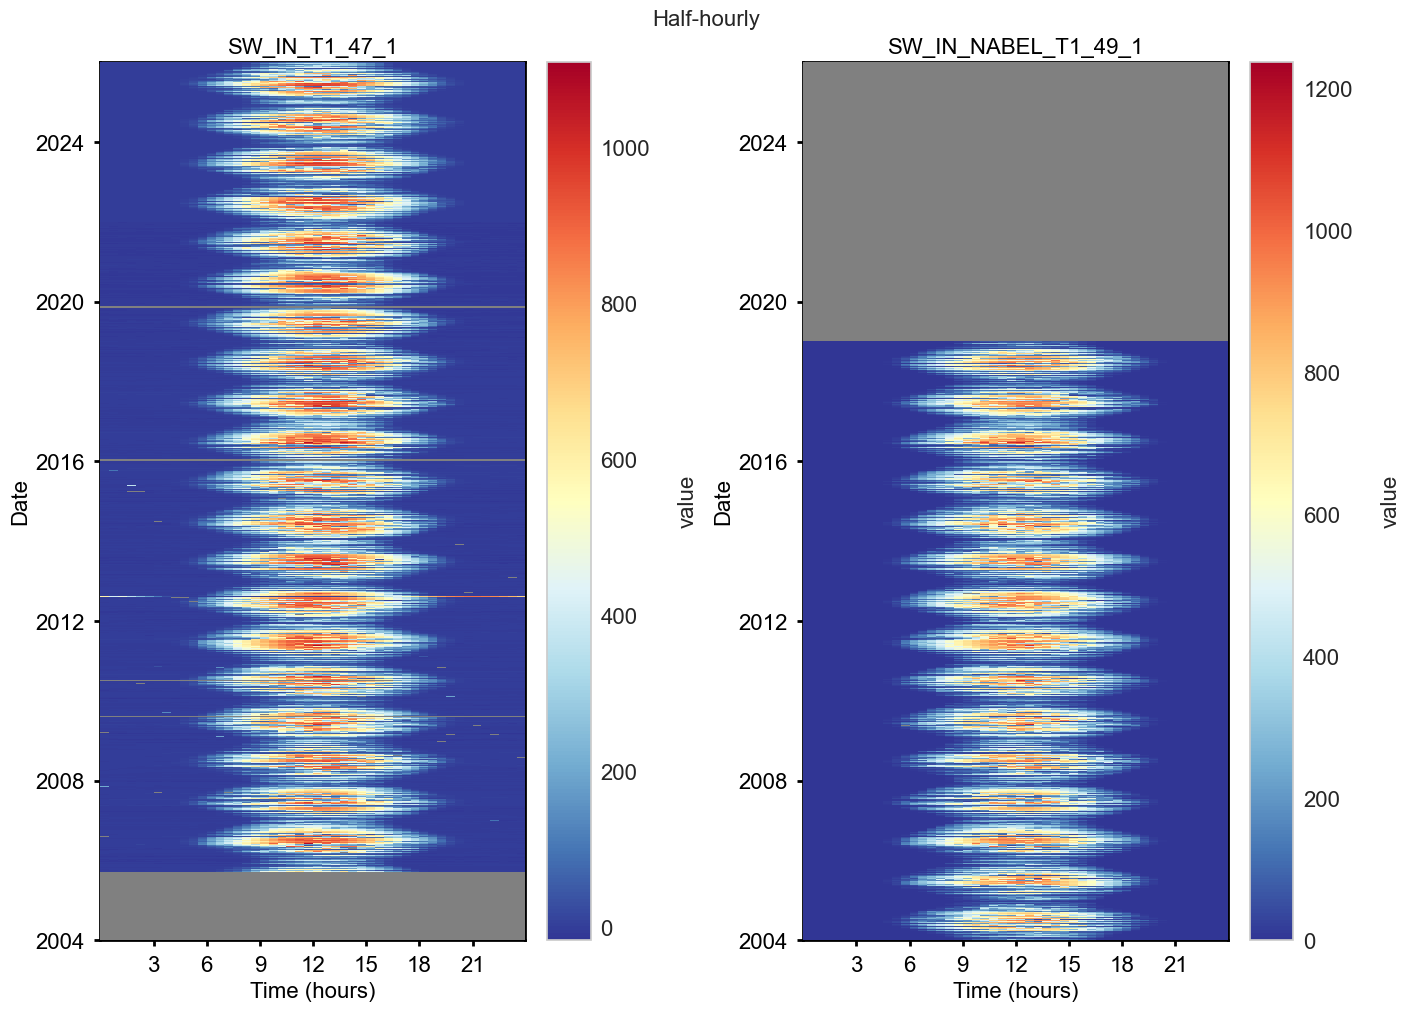

In [12]:
fig, axs = plt.subplots(ncols=2, figsize=(14, 10), dpi=100, layout="constrained")
fig.suptitle(f'Half-hourly', fontsize=16)
dv.heatmapdatetime(series=swin_2004_2025['SW_IN_T1_47_1'], title="SW_IN_T1_47_1", ax=axs[0], cb_digits_after_comma=0, zlabel="value").plot()
dv.heatmapdatetime(series=swin_2004_2025['SW_IN_NABEL_T1_49_1'], title="SW_IN_NABEL_T1_49_1", ax=axs[1], cb_digits_after_comma=0, zlabel="value").plot()

</br>

## Sanitize timestamp

In [13]:
swin_2004_2025 = TimestampSanitizer(data=swin_2004_2025, output_middle_timestamp=True).get()
swin_2004_2025

,SW_IN_NABEL_T1_49_1,SW_IN_T1_47_1
TIMESTAMP_MIDDLE,,
2004-01-01 00:15:00,0.0,NaN
2004-01-01 00:45:00,0.0,NaN
2004-01-01 01:15:00,0.0,NaN
2004-01-01 01:45:00,0.0,NaN
2004-01-01 02:15:00,0.0,NaN
...,...,...
2025-12-31 21:45:00,NaN,0.0
2025-12-31 22:15:00,NaN,0.0
2025-12-31 22:45:00,NaN,0.0


## Heatmap

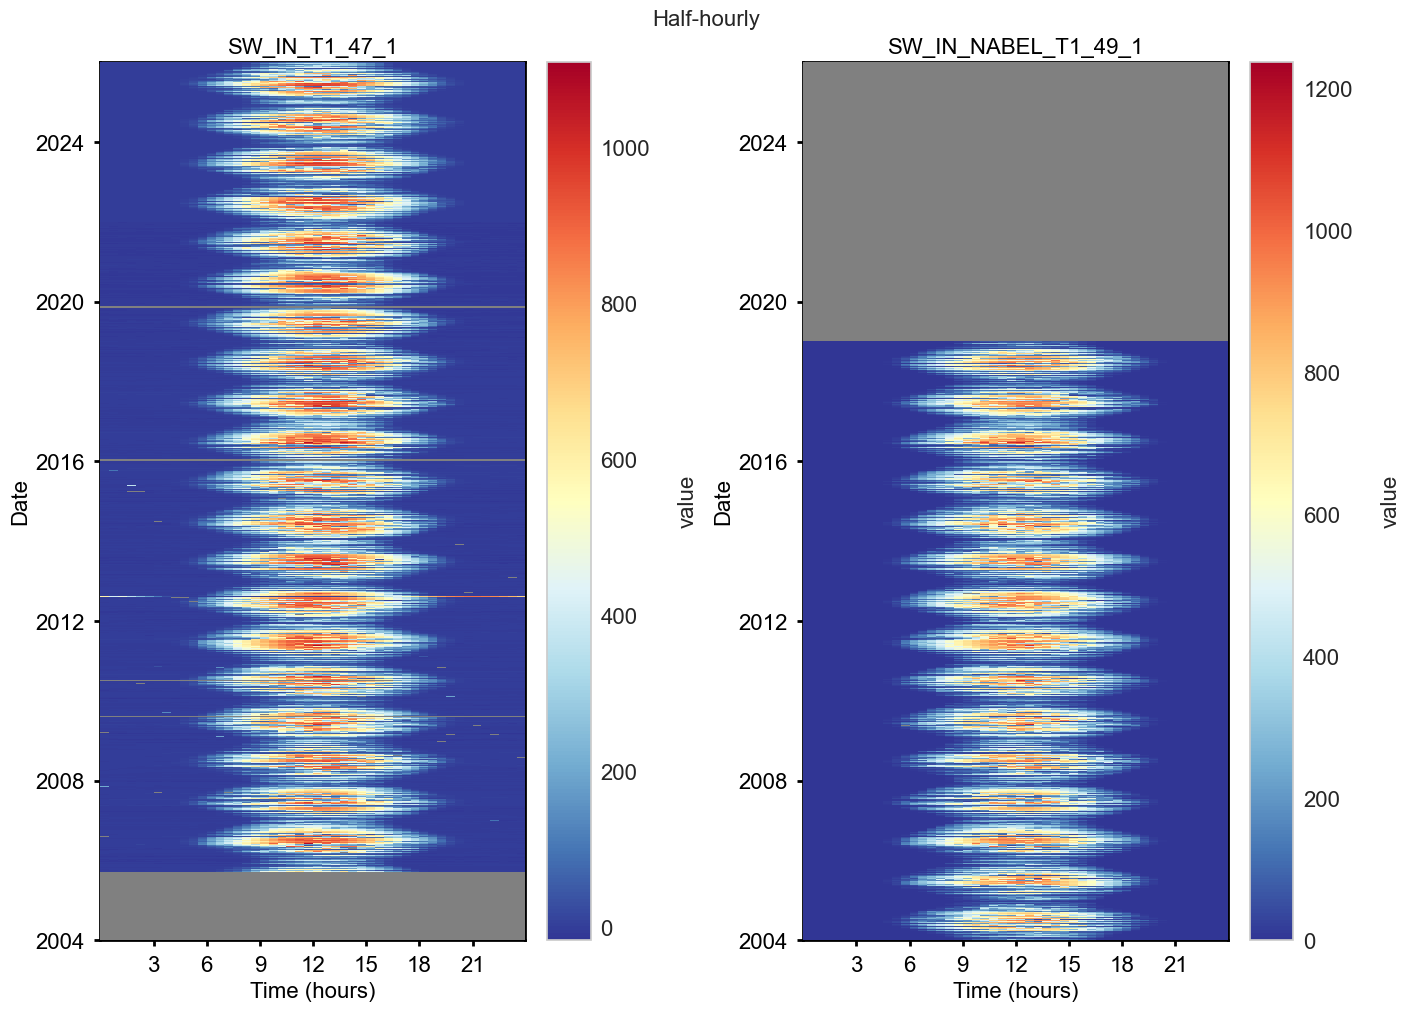

In [14]:
fig, axs = plt.subplots(ncols=2, figsize=(14, 10), dpi=100, layout="constrained")
fig.suptitle(f'Half-hourly', fontsize=16)
dv.heatmapdatetime(series=swin_2004_2025['SW_IN_T1_47_1'], title="SW_IN_T1_47_1", ax=axs[0], cb_digits_after_comma=0, zlabel="value").plot()
dv.heatmapdatetime(series=swin_2004_2025['SW_IN_NABEL_T1_49_1'], title="SW_IN_NABEL_T1_49_1", ax=axs[1], cb_digits_after_comma=0, zlabel="value").plot()

</br>

# ✴️ Corrections

### Timestamp shift in August 2012
**Info from fieldbook entry 17 Aug 2012:**
>   adjusted the logger date and time. On Servertime (Computer System Time) 17.08.2012 12:31.42 the loggertime was 16.08.2012 08:06:00. Synchronized time at 17.08.2012 11:40:00 servertime. The logger data aquisition on the moxa embedded was restarted

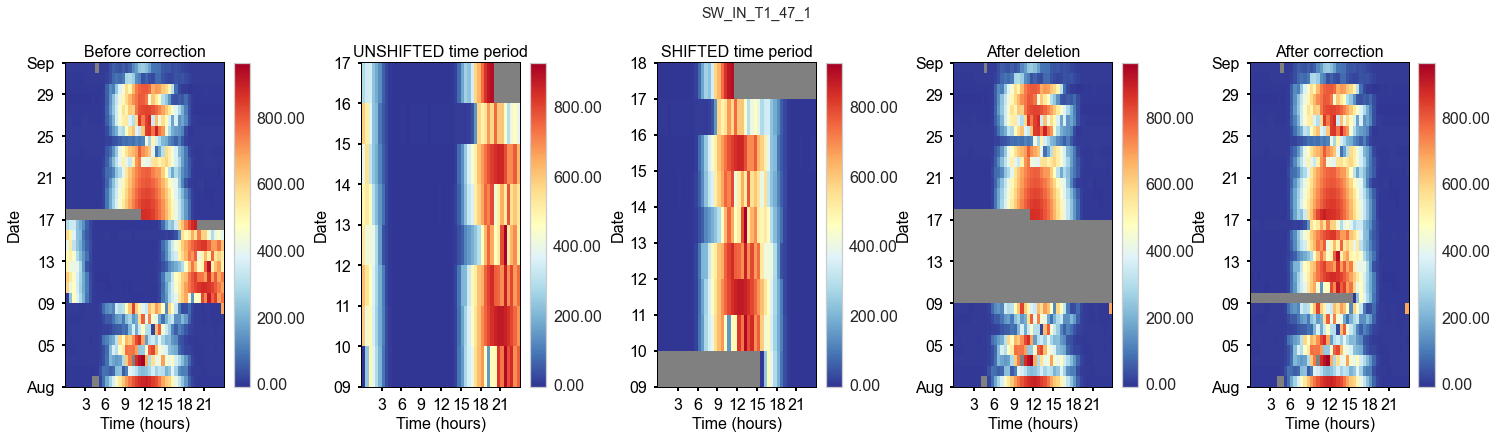

In [15]:
AFFECTED_VARS = ['SW_IN_T1_47_1']
_df = swin_2004_2025.copy()

for av in AFFECTED_VARS:
    fig = plt.figure(figsize=(24, 6), dpi=72)
    fig.suptitle(f"{av}")
    gs = gridspec.GridSpec(1, 5)  # rows, cols
    gs.update(wspace=0.5, hspace=1, left=.1, right=.9, top=.85, bottom=.1)
    ax_before = fig.add_subplot(gs[0, 0])
    ax_unshifted = fig.add_subplot(gs[0, 1])
    ax_shifted = fig.add_subplot(gs[0, 2])
    ax_after = fig.add_subplot(gs[0, 3])
    ax_corrected = fig.add_subplot(gs[0, 4])
    
    # Show time period around issue, before correction
    # _series = _df[av].copy()
    _show_locs = (_df.index >= '2012-08-01 00:00') & (_df.index <= '2012-09-01 00:00')
    dv.heatmapdatetime(series=_df.loc[_show_locs, av], ax=ax_before, title="Before correction").plot()
    
    # Get shifted time period
    _series_corrected = _df.loc[_show_locs, av].copy()
    # Identify shifted time period
    ISSUE_START = '2012-08-09 00:00'
    ISSUE_END = '2012-08-17 00:00'
    _shifted_locs = (_df.index >= ISSUE_START) & (_df.index <= ISSUE_END)
    _series_shifted = _df.loc[_shifted_locs, av].copy()
    _series_shifted = _series_shifted.dropna()
    dv.heatmapdatetime(series=_series_shifted, ax=ax_unshifted, title="UNSHIFTED time period").plot()
    
    # Shift SW_IN by 15.5 hours during shifted time period, create corrected time series
    _series_shifted.index = _series_shifted.index + pd.Timedelta(hours=15.5)
    dv.heatmapdatetime(series=_series_shifted, ax=ax_shifted, title="SHIFTED time period").plot()
    
    # Delete data between start of issue and the last timestamp of shifted data
    _overwrite_locs = (_df.index >= ISSUE_START) & (_df.index <= _series_shifted.index[-1])
    _df.loc[_overwrite_locs, av] = np.nan
    dv.heatmapdatetime(series=_df.loc[_show_locs, av], ax=ax_after, title="After deletion").plot()
    
    # Fill in corrected values
    _df.loc[_overwrite_locs, av] = _series_shifted
    # _series_corrected = _series_corrected.combine_first(_series_shifted)
    dv.heatmapdatetime(series=_df.loc[_show_locs, av], ax=ax_corrected, title="After correction").plot()
    
    # print(_series_shifted.index[-1])
    # print(_series_shifted)
    # print(_series_corrected[_overwrite_locs])

In [16]:
swin_2004_2025 = _df.copy()
swin_2004_2025

,SW_IN_NABEL_T1_49_1,SW_IN_T1_47_1
TIMESTAMP_MIDDLE,,
2004-01-01 00:15:00,0.0,NaN
2004-01-01 00:45:00,0.0,NaN
2004-01-01 01:15:00,0.0,NaN
2004-01-01 01:45:00,0.0,NaN
2004-01-01 02:15:00,0.0,NaN
...,...,...
2025-12-31 21:45:00,NaN,0.0
2025-12-31 22:15:00,NaN,0.0
2025-12-31 22:45:00,NaN,0.0


## Remove zero offset < 0 from `SW_IN`

In [17]:
swin_2004_2025.describe()

,SW_IN_NABEL_T1_49_1,SW_IN_T1_47_1
count,262774.000000,352940.000000
mean,140.037811,141.793897
std,233.701783,239.442523
min,0.000000,-16.722927
25%,0.000000,-2.890419
50%,2.506354,1.288768
75%,186.456335,192.305201
max,1236.721293,1109.351433


[remove_radiation_zero_offset]  running remove_radiation_zero_offset ...
[remove_radiation_zero_offset]  running remove_radiation_zero_offset ...


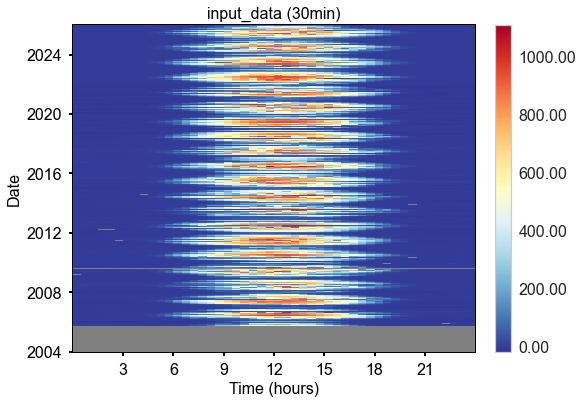

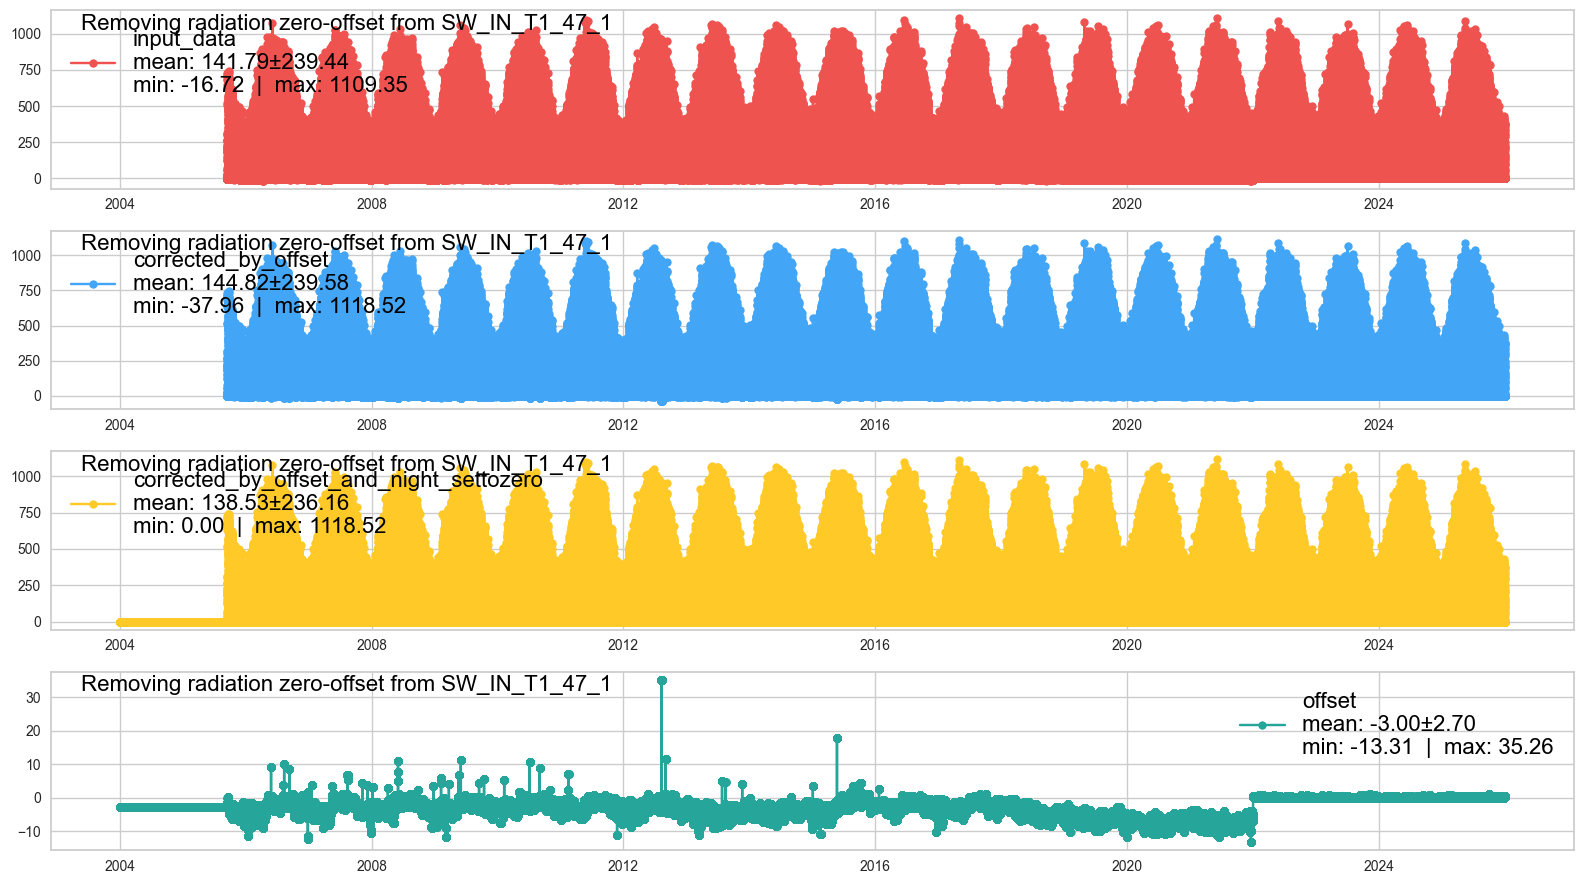

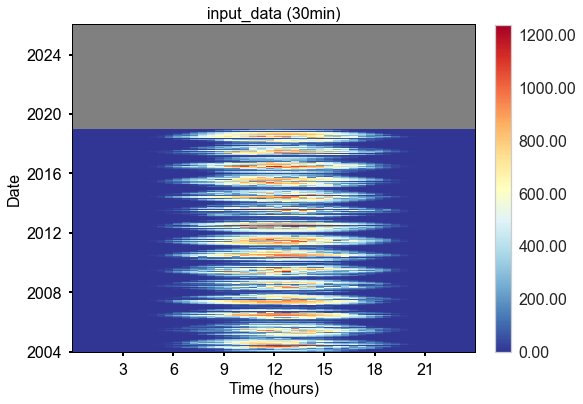

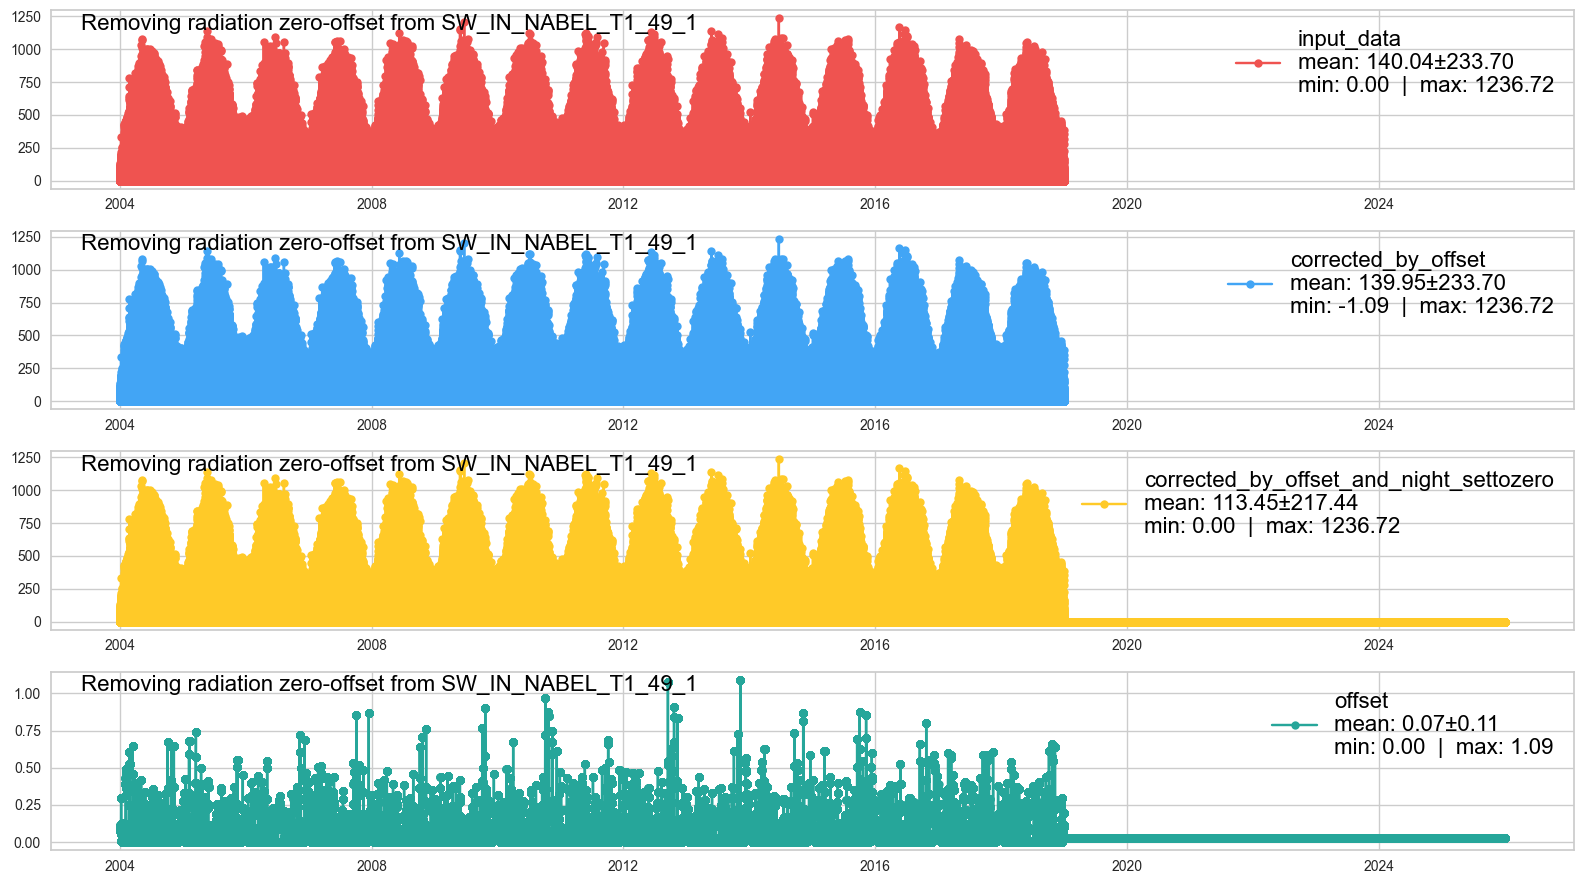

In [18]:
_swin = swin_2004_2025['SW_IN_T1_47_1'].copy()
_swin_corrected = remove_radiation_zero_offset(series=_swin, lat=SITE_LAT, lon=SITE_LON, utc_offset=1, showplot=True)
swin_2004_2025['SW_IN_T1_47_1'] = np.nan
swin_2004_2025['SW_IN_T1_47_1'] = _swin_corrected

_swin = swin_2004_2025['SW_IN_NABEL_T1_49_1'].copy()
_swin_corrected = remove_radiation_zero_offset(series=_swin, lat=SITE_LAT, lon=SITE_LON, utc_offset=1, showplot=True)
swin_2004_2025['SW_IN_NABEL_T1_49_1'] = np.nan
swin_2004_2025['SW_IN_NABEL_T1_49_1'] = _swin_corrected

## Dataframe

In [19]:
swin_2004_2025

,SW_IN_NABEL_T1_49_1,SW_IN_T1_47_1
TIMESTAMP_MIDDLE,,
2004-01-01 00:15:00,0.0,0.0
2004-01-01 00:45:00,0.0,0.0
2004-01-01 01:15:00,0.0,0.0
2004-01-01 01:45:00,0.0,0.0
2004-01-01 02:15:00,0.0,0.0
...,...,...
2025-12-31 21:45:00,0.0,0.0
2025-12-31 22:15:00,0.0,0.0
2025-12-31 22:45:00,0.0,0.0


In [20]:
swin_2004_2025.describe()

,SW_IN_NABEL_T1_49_1,SW_IN_T1_47_1
count,324158.000000,368973.000000
mean,113.449416,138.526769
std,217.436751,236.156515
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,112.678645,177.567358
max,1236.721293,1118.523355


</br>

</br>

# 🟪 Prepare dataframes

In [21]:
swin_2004_2018 = swin_2004_2025.loc[swin_2004_2025.index.year <= 2018].copy()
swin_2004_2018

,SW_IN_NABEL_T1_49_1,SW_IN_T1_47_1
TIMESTAMP_MIDDLE,,
2004-01-01 00:15:00,0.0,0.0
2004-01-01 00:45:00,0.0,0.0
2004-01-01 01:15:00,0.0,0.0
2004-01-01 01:45:00,0.0,0.0
2004-01-01 02:15:00,0.0,0.0
...,...,...
2018-12-31 21:45:00,0.0,0.0
2018-12-31 22:15:00,0.0,0.0
2018-12-31 22:45:00,0.0,0.0


In [22]:
swin_2019_2025 = swin_2004_2025.loc[swin_2004_2025.index.year >= 2019].copy()
swin_2019_2025

,SW_IN_NABEL_T1_49_1,SW_IN_T1_47_1
TIMESTAMP_MIDDLE,,
2019-01-01 00:15:00,0.0,0.0
2019-01-01 00:45:00,0.0,0.0
2019-01-01 01:15:00,0.0,0.0
2019-01-01 01:45:00,0.0,0.0
2019-01-01 02:15:00,0.0,0.0
...,...,...
2025-12-31 21:45:00,0.0,0.0
2025-12-31 22:15:00,0.0,0.0
2025-12-31 22:45:00,0.0,0.0


</br>

</br>

# 🟥 Gap-filling NABEL (2004-2018)

## Target and features - daytime only

In [23]:
TARGET = "SW_IN_NABEL_T1_49_1"
subset = pd.DataFrame()
subset = swin_2004_2018[['SW_IN_NABEL_T1_49_1']].copy()
subset['SW_IN_POT'] = potrad(timestamp_index=subset.index, lat=SITE_LAT, lon=SITE_LON, utc_offset=1)
subset = subset.loc[subset['SW_IN_POT'] > 0, :].copy()
display(subset)
subset.describe()

,SW_IN_NABEL_T1_49_1,SW_IN_POT
TIMESTAMP_MIDDLE,,
2004-01-01 08:45:00,16.572917,87.881303
2004-01-01 09:15:00,26.239583,174.686134
2004-01-01 09:45:00,28.906250,251.779510
2004-01-01 10:15:00,28.906250,317.842341
2004-01-01 10:45:00,32.906250,371.744274
...,...,...
2018-12-31 14:15:00,68.808474,358.576027
2018-12-31 14:45:00,62.835041,301.817806
2018-12-31 15:15:00,54.623841,233.149089


,SW_IN_NABEL_T1_49_1,SW_IN_POT
count,131246.000000,131464.000000
mean,280.203097,591.683737
std,264.663366,346.277171
min,0.000000,0.281998
25%,57.801903,313.253098
50%,186.762057,552.708888
75%,451.128349,876.992362
max,1236.721293,1241.991455


## Initialize gap-filling

In [24]:
xgbts = XGBoostTS(
    input_df=subset,
    target_col=TARGET,
    verbose=1,
    features_lag=None,
    features_lag_exclude_cols=None,
    vectorize_timestamps=True,
    add_continuous_record_number=True,
    sanitize_timestamp=False,
    perm_n_repeats=1,
    n_estimators=3000,    
    random_state=42,
    # booster='gbtree',  # gbtree (default), gblinear, dart
    # device='cpu',
    # validate_parameters=True,
    # disable_default_eval_metric=False,
    early_stopping_rounds=100,
    # learning_rate=0.1,
    # max_depth=9,
    # max_delta_step=0,
    # subsample=1,
    # min_split_loss=0,
    # min_child_weight=1,
    # colsample_bytree=1,
    # colsample_bylevel=1,
    # colsample_bynode=1,
    # reg_lambda=1,
    # reg_alpha=0,
    # tree_method='auto',  # auto, hist, approx, exact
    # scale_pos_weight=1,
    # grow_policy='depthwise',  # depthwise, lossguide
    # max_leaves=0,
    # max_bin=256,
    # num_parallel_tree=1,
    n_jobs=-1
)



Starting gap-filling for
SW_IN_NABEL_T1_49_1
using <class 'xgboost.sklearn.XGBRegressor'>

Adding new data columns ...
++ Added new columns with timestamp info: ['.YEAR', '.SEASON', '.SEASON_SIN', '.SEASON_COS', '.MONTH', '.MONTH_SIN', '.MONTH_COS', '.WEEK', '.WEEK_SIN', '.WEEK_COS', '.DOY', '.DOY_SIN', '.DOY_COS', '.HOUR', '.HOUR_SIN', '.HOUR_COS', '.YEARMONTH', '.YEARDOY', '.YEARWEEK'] 
++ Added new column .RECORDNUMBER with record numbers from 1 to 131464.


## Reduce features across years

In [25]:
xgbts.reduce_features()
xgbts.report_feature_reduction()


[ FEATURE REDUCTION ] Feature reduction based on permutation importance ...
[0]	validation_0-rmse:222.06890	validation_1-rmse:222.06890
[1]	validation_0-rmse:197.55955	validation_1-rmse:197.55955
[2]	validation_0-rmse:184.11364	validation_1-rmse:184.11364
[3]	validation_0-rmse:176.84330	validation_1-rmse:176.84330
[4]	validation_0-rmse:172.48057	validation_1-rmse:172.48057
[5]	validation_0-rmse:170.29504	validation_1-rmse:170.29504
[6]	validation_0-rmse:168.78609	validation_1-rmse:168.78609
[7]	validation_0-rmse:167.54043	validation_1-rmse:167.54043
[8]	validation_0-rmse:166.18667	validation_1-rmse:166.18667
[9]	validation_0-rmse:165.67960	validation_1-rmse:165.67960
[10]	validation_0-rmse:164.87640	validation_1-rmse:164.87640
[11]	validation_0-rmse:164.23147	validation_1-rmse:164.23147
[12]	validation_0-rmse:163.31823	validation_1-rmse:163.31823
[13]	validation_0-rmse:162.36645	validation_1-rmse:162.36645
[14]	validation_0-rmse:161.34045	validation_1-rmse:161.34045
[15]	validation_0-

## Train model


Training final model ...
>>> Training model <class 'xgboost.sklearn.XGBRegressor'> based on data between 2004-01-01 09:15:00 and 2018-12-31 16:15:00 ...
>>> Fitting model to training data ...
[0]	validation_0-rmse:222.07584	validation_1-rmse:221.96541
[1]	validation_0-rmse:197.57593	validation_1-rmse:197.81747
[2]	validation_0-rmse:184.13797	validation_1-rmse:184.62416
[3]	validation_0-rmse:176.79322	validation_1-rmse:177.46391
[4]	validation_0-rmse:172.66314	validation_1-rmse:173.63043
[5]	validation_0-rmse:170.47815	validation_1-rmse:171.61412
[6]	validation_0-rmse:168.91613	validation_1-rmse:170.23264
[7]	validation_0-rmse:167.79754	validation_1-rmse:169.25720
[8]	validation_0-rmse:167.19171	validation_1-rmse:168.66090
[9]	validation_0-rmse:166.37701	validation_1-rmse:168.03199
[10]	validation_0-rmse:165.50189	validation_1-rmse:167.26555
[11]	validation_0-rmse:164.80130	validation_1-rmse:166.63660
[12]	validation_0-rmse:163.37683	validation_1-rmse:165.23345
[13]	validation_0-rmse:1

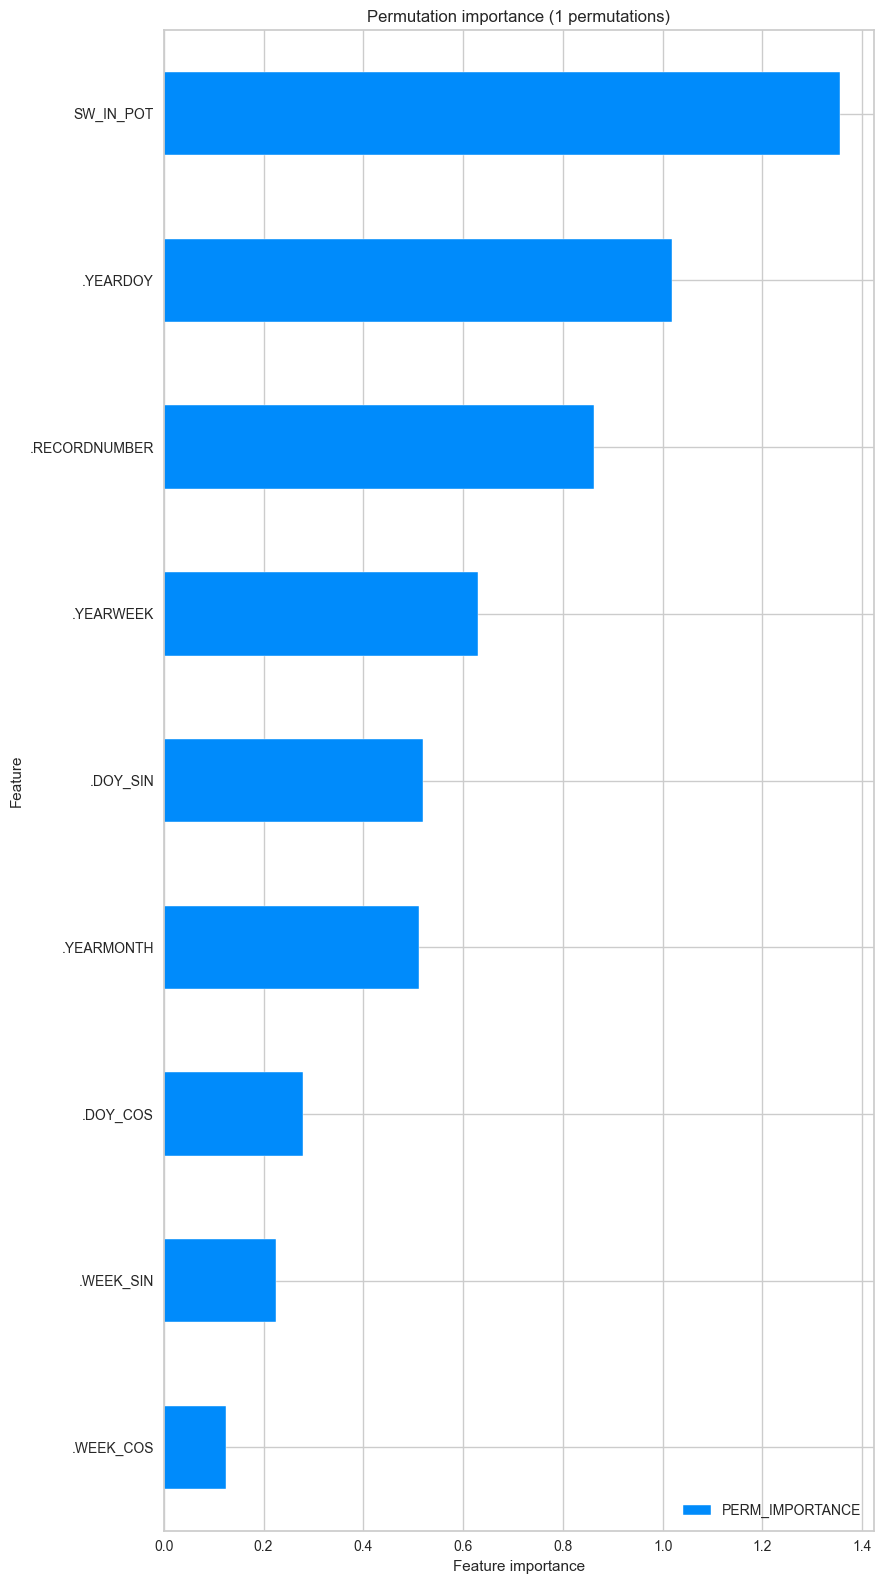

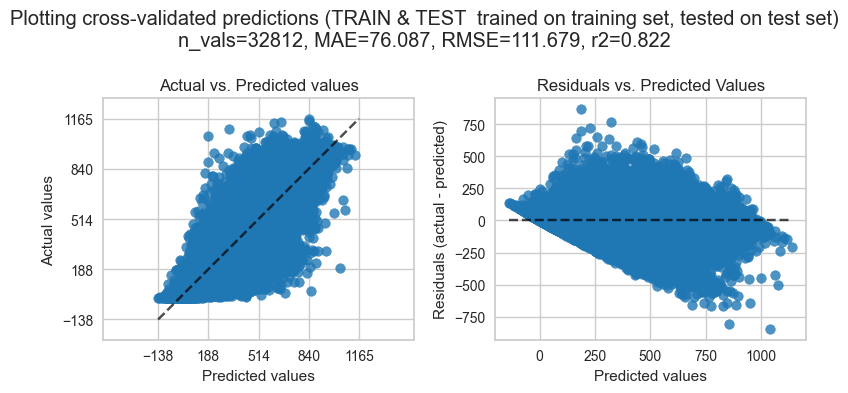

>>> Plotting residuals and prediction error ...


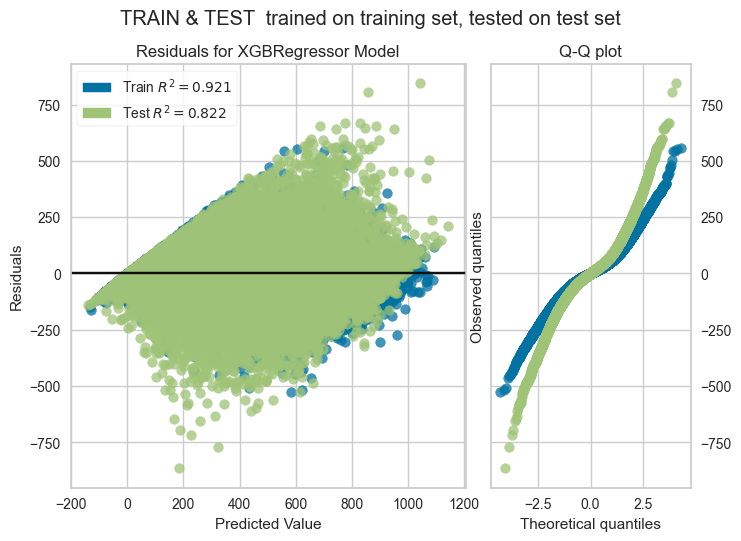

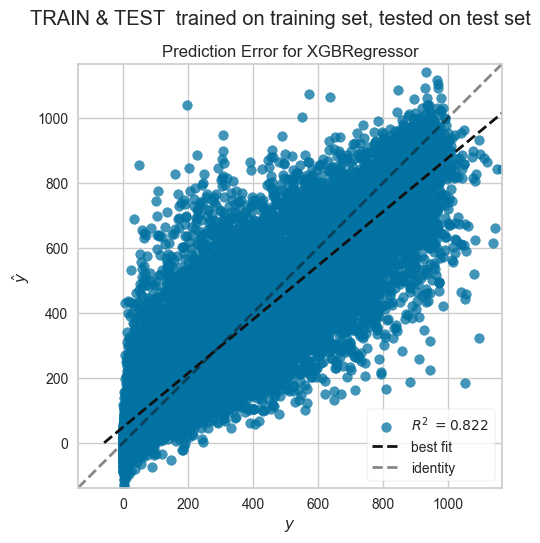

>>> Collecting results, details about training and testing can be accessed by calling .report_traintest().
>>> Done.

MODEL TRAINING & TESTING RESULTS

## DATA
  > target: SW_IN_NABEL_T1_49_1
  > features: 9 ['SW_IN_POT', '.RECORDNUMBER', '.YEARMONTH', '.YEARDOY', '.YEARWEEK', '.DOY_SIN', '.WEEK_SIN', '.DOY_COS', '.WEEK_COS']
  > 131464 records (with missing)
  > 131246 available records for target and all features (no missing values)
  > training on 98434 records (75.0%) of 98434 features between 2004-01-01 09:15:00 and 2018-12-31 16:15:00
  > testing on 32812 unseen records (25.0%) of SW_IN_NABEL_T1_49_1 between 2004-01-01 08:45:00 and 2018-12-31 15:45:00

## MODEL
  > the model was trained on training data (98434 records)
  > the model was tested on test data (32812 values)
  > estimator:  XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=100,


In [26]:
xgbts.trainmodel(showplot_scores=True, showplot_importance=True)
xgbts.report_traintest()

## Fill gaps


Gap-filling using final model ...
>>> Using final model on all data to predict target SW_IN_NABEL_T1_49_1 ...
>>> Using final model on all data to calculate permutation importance ...
>>> Plotting feature importances (permutation importance) ...
>>> Calculating prediction scores based on all data predicting SW_IN_NABEL_T1_49_1 ...
>>> Plotting observed and predicted values based on all data ...


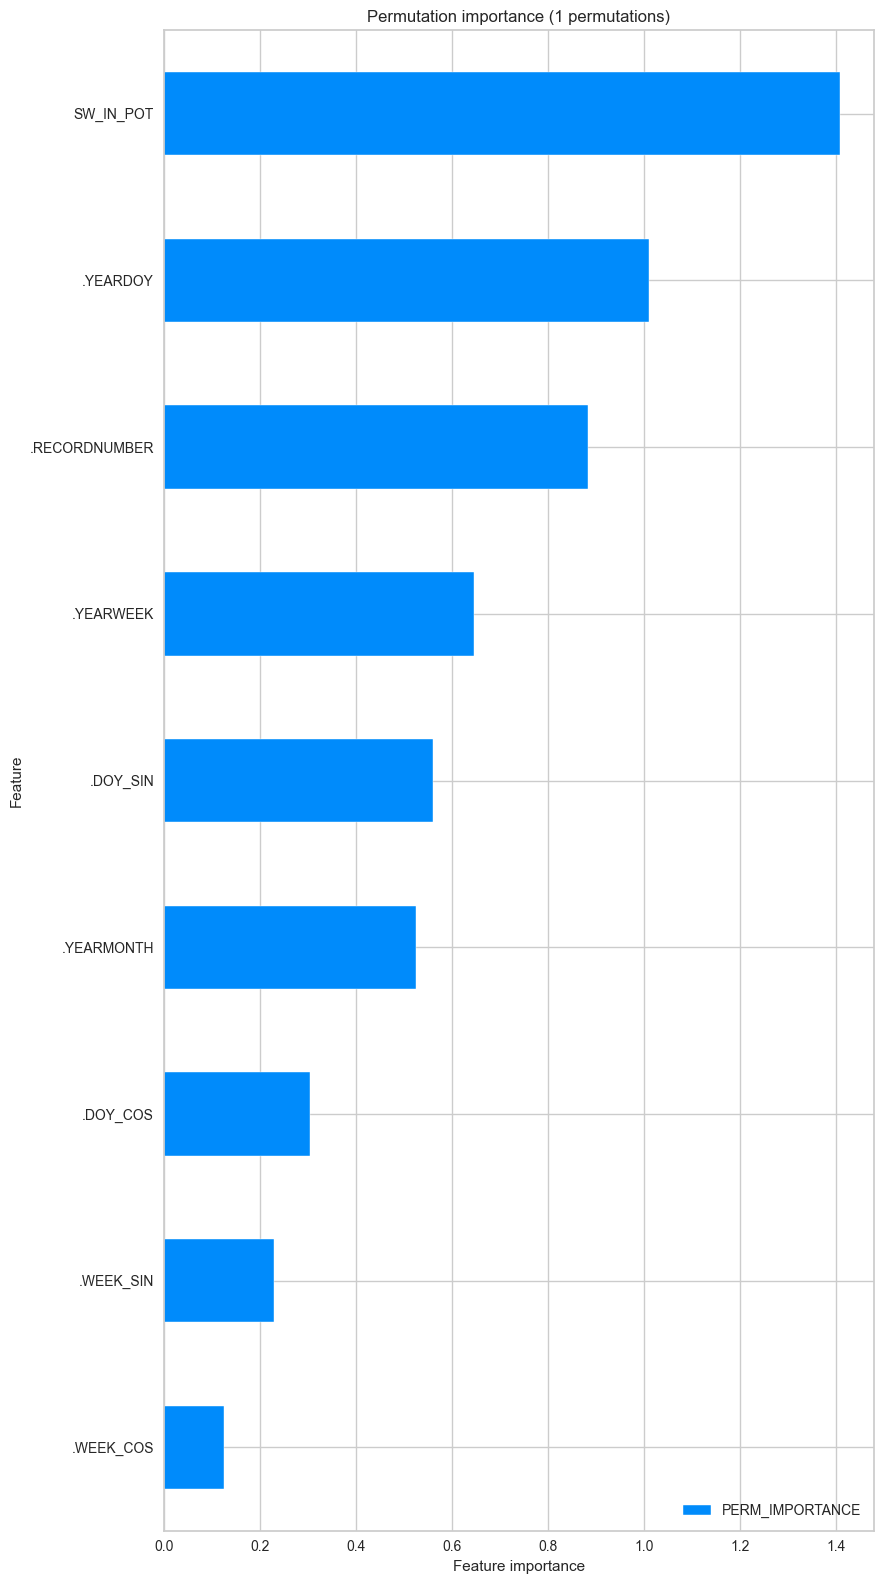

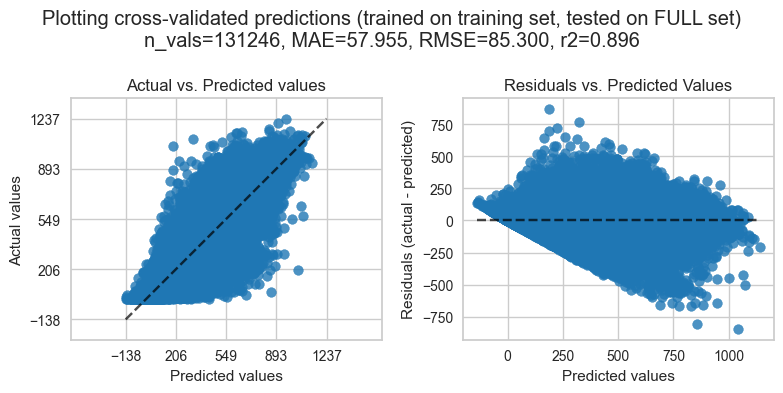

>>> Predicting target SW_IN_NABEL_T1_49_1 where all features are available ... predicted 131464 records.
>>> Collecting results for final model ...
>>> Filling 218 missing records in target with predictions from final model ...
>>> Storing gap-filled time series in variable SW_IN_NABEL_T1_49_1_gfXG ...
>>> Restoring original timestamp in results ...

Gap-filling 0 remaining missing records in SW_IN_NABEL_T1_49_1_gfXG using fallback model ...
>>> Fallback model not necessary, all gaps were already filled.
>>> Combining predictions from full model and fallback model ...

GAP-FILLING RESULTS

Model scores and feature importances were calculated from high-quality predicted targets (218 values, SW_IN_NABEL_T1_49_1_gfXG where flag=1) in comparison to observed targets (131246 values, SW_IN_NABEL_T1_49_1).

## TARGET
- first timestamp:  2004-01-01 08:45:00
- last timestamp:  2018-12-31 16:15:00
- potential number of values: 131464 values)
- target column (observed):  SW_IN_NABEL_T1_49_1
- miss

In [27]:
xgbts.fillgaps(showplot_scores=True, showplot_importance=True)
xgbts.report_gapfilling()

## Results: yearly scores

In [28]:
xgbts.scores_

{'mae': 57.95487293889372,
 'medae': np.float64(37.59763887652229),
 'mse': 7276.157816263588,
 'rmse': 85.30039751527298,
 'mape': 16223637227610.371,
 'maxe': np.float64(866.5523333333333),
 'r2': 0.896123393134372}

## Results: feature importances

In [29]:
xgbts.feature_importances_

,PERM_IMPORTANCE,PERM_SD
SW_IN_POT,1.408794,0.0
.YEARDOY,1.011513,0.0
.RECORDNUMBER,0.883965,0.0
.YEARWEEK,0.645085,0.0
.DOY_SIN,0.560690,0.0
.YEARMONTH,0.525373,0.0
.DOY_COS,0.304965,0.0
.WEEK_SIN,0.228779,0.0
.WEEK_COS,0.124936,0.0


## Results: plot gap-filled time series

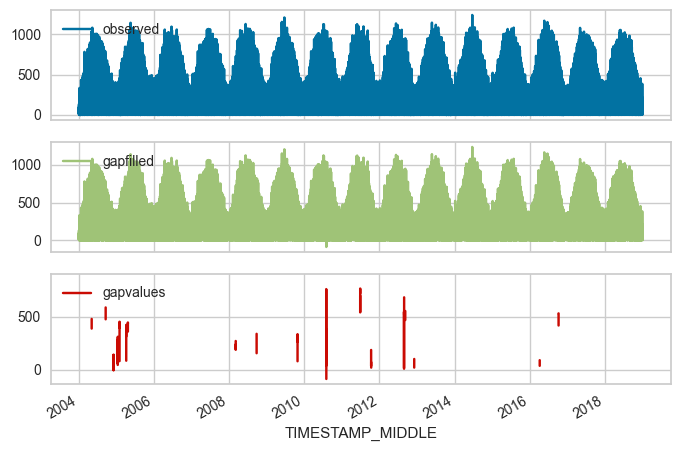

In [30]:
observed = subset[TARGET]
gapfilled = xgbts.get_gapfilled_target()
locs_filled = observed.isna()
gapvalues = gapfilled[locs_filled].copy()
# gapfilled[locs_filled].describe()
_plotdf = pd.DataFrame({
    'observed': observed,
    'gapfilled': gapfilled,
    'gapvalues': gapvalues
})
_plotdf.plot(subplots=True, x_compat=True);

## Add gap-filled daytime series to dataframe and add nighttime data

In [35]:
swin_2004_2018[gapfilled.name] = gapfilled
swin_2004_2018[gapfilled.name] = swin_2004_2018[gapfilled.name].fillna(swin_2004_2018[TARGET])

## Plot time series

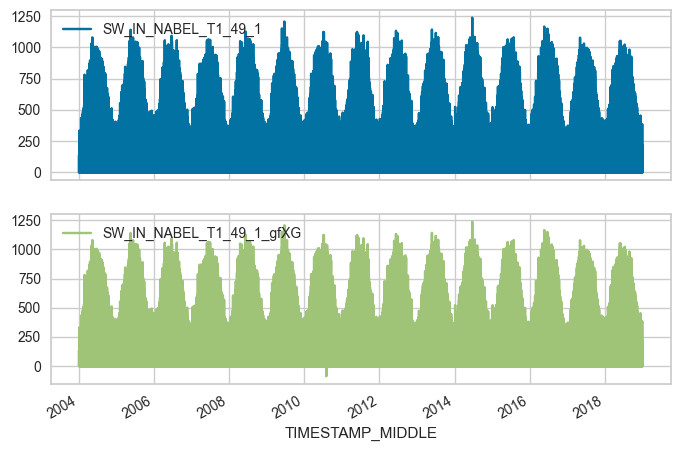

In [36]:
swin_2004_2018[[TARGET, gapfilled.name]].plot(subplots=True, x_compat=True);

## Correction: Remove zero values
- In this case this is not a measurement offset, but an artifact introduced by XGB
- Additional correction needed because gap-filling introduced values < 0

In [37]:
swin_2004_2018[[TARGET, gapfilled.name]].describe()

,SW_IN_NABEL_T1_49_1,SW_IN_NABEL_T1_49_1_gfXG
count,262774.000000,262992.000000
mean,139.951196,140.050839
std,233.696653,233.695965
min,0.000000,-86.578979
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,186.338463,186.771366
max,1236.721293,1236.721293


In [38]:
swin_2004_2018[gapfilled.name].loc[swin_2004_2018[gapfilled.name] < 0] = 0
swin_2004_2018[[TARGET, gapfilled.name]].describe()

,SW_IN_NABEL_T1_49_1,SW_IN_NABEL_T1_49_1_gfXG
count,262774.000000,262992.000000
mean,139.951196,140.052094
std,233.696653,233.695053
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,186.338463,186.771366
max,1236.721293,1236.721293


In [ ]:
# _swin = swin_2004_2025[gapfilled.name].copy()
# _swin_corrected = remove_radiation_zero_offset(series=_swin, lat=SITE_LAT, lon=SITE_LON, utc_offset=1, showplot=True)
# swin_2004_2025[gapfilled.name] = np.nan
# swin_2004_2025[gapfilled.name] = _swin_corrected

</br>

## Dataframe

In [39]:
swin_2004_2018

,SW_IN_NABEL_T1_49_1,SW_IN_T1_47_1,SW_IN_NABEL_T1_49_1_gfXG
TIMESTAMP_MIDDLE,,,
2004-01-01 00:15:00,0.0,0.0,0.0
2004-01-01 00:45:00,0.0,0.0,0.0
2004-01-01 01:15:00,0.0,0.0,0.0
2004-01-01 01:45:00,0.0,0.0,0.0
2004-01-01 02:15:00,0.0,0.0,0.0
...,...,...,...
2018-12-31 21:45:00,0.0,0.0,0.0
2018-12-31 22:15:00,0.0,0.0,0.0
2018-12-31 22:45:00,0.0,0.0,0.0


</br>

</br>

</br>

# 🟥 Gap-filling ETH (2004-2018) using NABEL+
- NABEL is now complete (no gaps) 2004-2018 and can be used as feature in those years

## Target and features - daytime only

In [40]:
TARGET = "SW_IN_T1_47_1"
subset = pd.DataFrame()
subset = swin_2004_2018[[TARGET, 'SW_IN_NABEL_T1_49_1_gfXG']].copy()
subset['SW_IN_POT'] = potrad(timestamp_index=subset.index, lat=SITE_LAT, lon=SITE_LON, utc_offset=1)
subset = subset.loc[subset['SW_IN_POT'] > 0, :].copy()
display(subset)
subset.describe()

,SW_IN_T1_47_1,SW_IN_NABEL_T1_49_1_gfXG,SW_IN_POT
TIMESTAMP_MIDDLE,,,
2004-01-01 08:45:00,NaN,16.572917,87.881303
2004-01-01 09:15:00,NaN,26.239583,174.686134
2004-01-01 09:45:00,NaN,28.906250,251.779510
2004-01-01 10:15:00,NaN,28.906250,317.842341
2004-01-01 10:45:00,NaN,32.906250,371.744274
...,...,...,...
2018-12-31 14:15:00,68.808479,68.808474,358.576027
2018-12-31 14:45:00,62.835003,62.835041,301.817806
2018-12-31 15:15:00,54.623865,54.623841,233.149089


,SW_IN_T1_47_1,SW_IN_NABEL_T1_49_1_gfXG,SW_IN_POT
count,115089.000000,131464.000000,131464.000000
mean,285.608960,280.172368,591.683737
std,267.269842,264.566873,346.277171
min,0.000000,0.000000,0.281998
25%,59.122981,57.844646,313.253098
50%,191.227454,186.848434,552.708888
75%,463.085708,450.954147,876.992362
max,1110.752843,1236.721293,1241.991455


## Initialize gap-filling

In [41]:
xgbts = XGBoostTS(
    input_df=subset,
    target_col=TARGET,
    verbose=1,
    features_lag=None,
    features_lag_exclude_cols=None,
    vectorize_timestamps=True,
    add_continuous_record_number=True,
    sanitize_timestamp=False,
    perm_n_repeats=1,
    n_estimators=3000,    
    random_state=42,
    # booster='gbtree',  # gbtree (default), gblinear, dart
    # device='cpu',
    # validate_parameters=True,
    # disable_default_eval_metric=False,
    early_stopping_rounds=100,
    # learning_rate=0.1,
    # max_depth=9,
    # max_delta_step=0,
    # subsample=1,
    # min_split_loss=0,
    # min_child_weight=1,
    # colsample_bytree=1,
    # colsample_bylevel=1,
    # colsample_bynode=1,
    # reg_lambda=1,
    # reg_alpha=0,
    # tree_method='auto',  # auto, hist, approx, exact
    # scale_pos_weight=1,
    # grow_policy='depthwise',  # depthwise, lossguide
    # max_leaves=0,
    # max_bin=256,
    # num_parallel_tree=1,
    n_jobs=-1
)



Starting gap-filling for
SW_IN_T1_47_1
using <class 'xgboost.sklearn.XGBRegressor'>

Adding new data columns ...
++ Added new columns with timestamp info: ['.YEAR', '.SEASON', '.SEASON_SIN', '.SEASON_COS', '.MONTH', '.MONTH_SIN', '.MONTH_COS', '.WEEK', '.WEEK_SIN', '.WEEK_COS', '.DOY', '.DOY_SIN', '.DOY_COS', '.HOUR', '.HOUR_SIN', '.HOUR_COS', '.YEARMONTH', '.YEARDOY', '.YEARWEEK'] 
++ Added new column .RECORDNUMBER with record numbers from 1 to 131464.


## Reduce features across years

In [42]:
xgbts.reduce_features()
xgbts.report_feature_reduction()


[ FEATURE REDUCTION ] Feature reduction based on permutation importance ...
[0]	validation_0-rmse:189.68568	validation_1-rmse:189.68568
[1]	validation_0-rmse:135.98973	validation_1-rmse:135.98973
[2]	validation_0-rmse:99.47269	validation_1-rmse:99.47269
[3]	validation_0-rmse:75.23913	validation_1-rmse:75.23913
[4]	validation_0-rmse:59.79088	validation_1-rmse:59.79088
[5]	validation_0-rmse:50.38023	validation_1-rmse:50.38023
[6]	validation_0-rmse:44.97804	validation_1-rmse:44.97804
[7]	validation_0-rmse:41.92786	validation_1-rmse:41.92786
[8]	validation_0-rmse:40.30730	validation_1-rmse:40.30730
[9]	validation_0-rmse:39.18102	validation_1-rmse:39.18102
[10]	validation_0-rmse:38.64058	validation_1-rmse:38.64058
[11]	validation_0-rmse:38.12173	validation_1-rmse:38.12173
[12]	validation_0-rmse:37.87377	validation_1-rmse:37.87377
[13]	validation_0-rmse:37.54270	validation_1-rmse:37.54270
[14]	validation_0-rmse:37.17942	validation_1-rmse:37.17942
[15]	validation_0-rmse:36.99215	validation_1

## Train model


Training final model ...
>>> Training model <class 'xgboost.sklearn.XGBRegressor'> based on data between 2005-09-14 11:45:00 and 2018-12-31 16:15:00 ...
>>> Fitting model to training data ...
[0]	validation_0-rmse:189.70558	validation_1-rmse:188.92441
[1]	validation_0-rmse:136.04239	validation_1-rmse:135.65790
[2]	validation_0-rmse:99.60899	validation_1-rmse:99.48206
[3]	validation_0-rmse:75.44956	validation_1-rmse:75.58076
[4]	validation_0-rmse:60.01464	validation_1-rmse:60.35099
[5]	validation_0-rmse:50.64424	validation_1-rmse:51.14413
[6]	validation_0-rmse:45.19857	validation_1-rmse:45.86784
[7]	validation_0-rmse:42.13411	validation_1-rmse:42.90932
[8]	validation_0-rmse:40.50524	validation_1-rmse:41.35119
[9]	validation_0-rmse:39.58959	validation_1-rmse:40.54628
[10]	validation_0-rmse:38.95928	validation_1-rmse:39.98248
[11]	validation_0-rmse:38.51576	validation_1-rmse:39.67918
[12]	validation_0-rmse:38.24756	validation_1-rmse:39.50702
[13]	validation_0-rmse:38.06024	validation_1-r

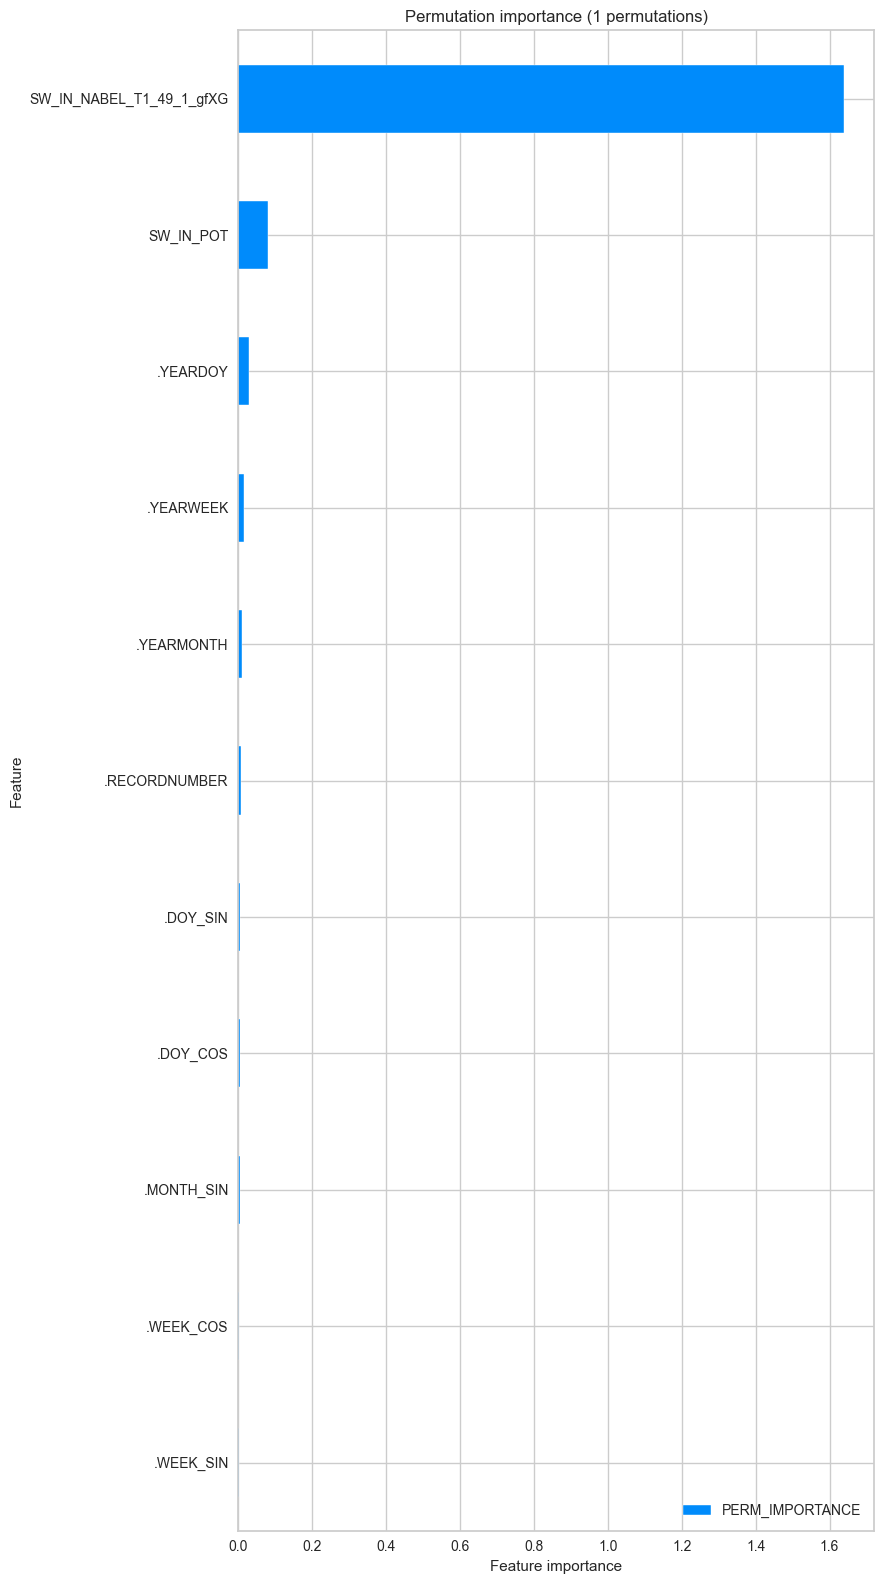

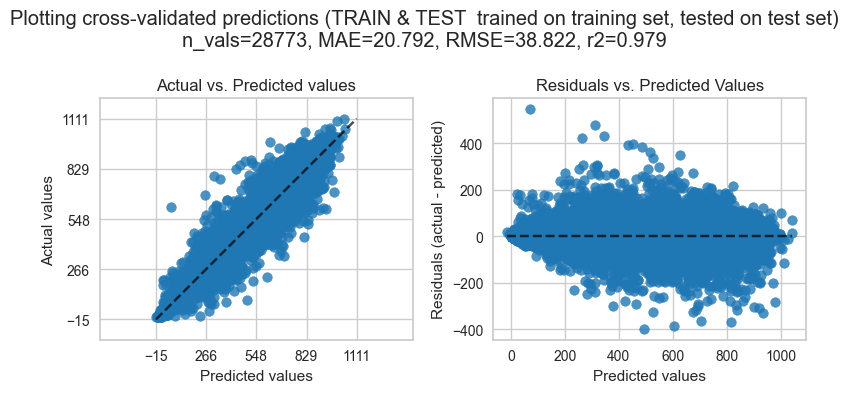

>>> Plotting residuals and prediction error ...


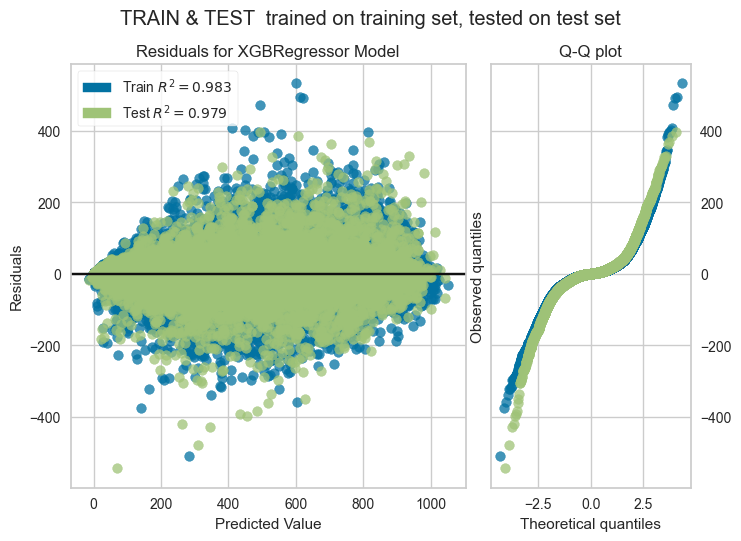

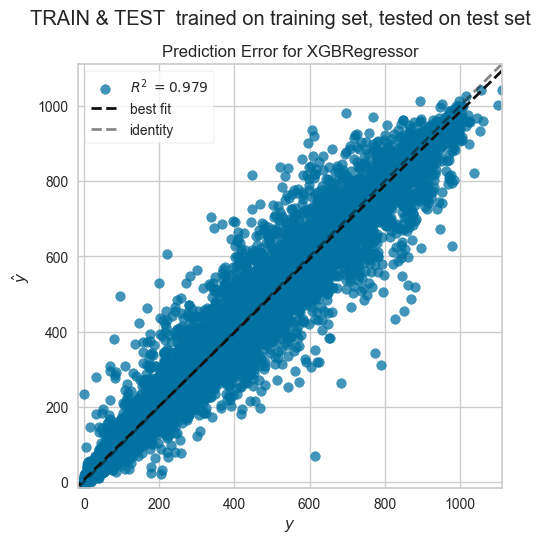

>>> Collecting results, details about training and testing can be accessed by calling .report_traintest().
>>> Done.

MODEL TRAINING & TESTING RESULTS

## DATA
  > target: SW_IN_T1_47_1
  > features: 11 ['SW_IN_NABEL_T1_49_1_gfXG', 'SW_IN_POT', '.YEARDOY', '.YEARWEEK', '.RECORDNUMBER', '.YEARMONTH', '.DOY_SIN', '.WEEK_COS', '.DOY_COS', '.MONTH_SIN', '.WEEK_SIN']
  > 131464 records (with missing)
  > 115089 available records for target and all features (no missing values)
  > training on 86316 records (75.0%) of 86316 features between 2005-09-14 11:45:00 and 2018-12-31 16:15:00
  > testing on 28773 unseen records (25.0%) of SW_IN_T1_47_1 between 2005-09-14 11:15:00 and 2018-12-31 12:45:00

## MODEL
  > the model was trained on training data (86316 records)
  > the model was tested on test data (28773 values)
  > estimator:  XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=No

In [43]:
xgbts.trainmodel(showplot_scores=True, showplot_importance=True)
xgbts.report_traintest()

## Fill gaps


Gap-filling using final model ...
>>> Using final model on all data to predict target SW_IN_T1_47_1 ...
>>> Using final model on all data to calculate permutation importance ...
>>> Plotting feature importances (permutation importance) ...
>>> Calculating prediction scores based on all data predicting SW_IN_T1_47_1 ...
>>> Plotting observed and predicted values based on all data ...


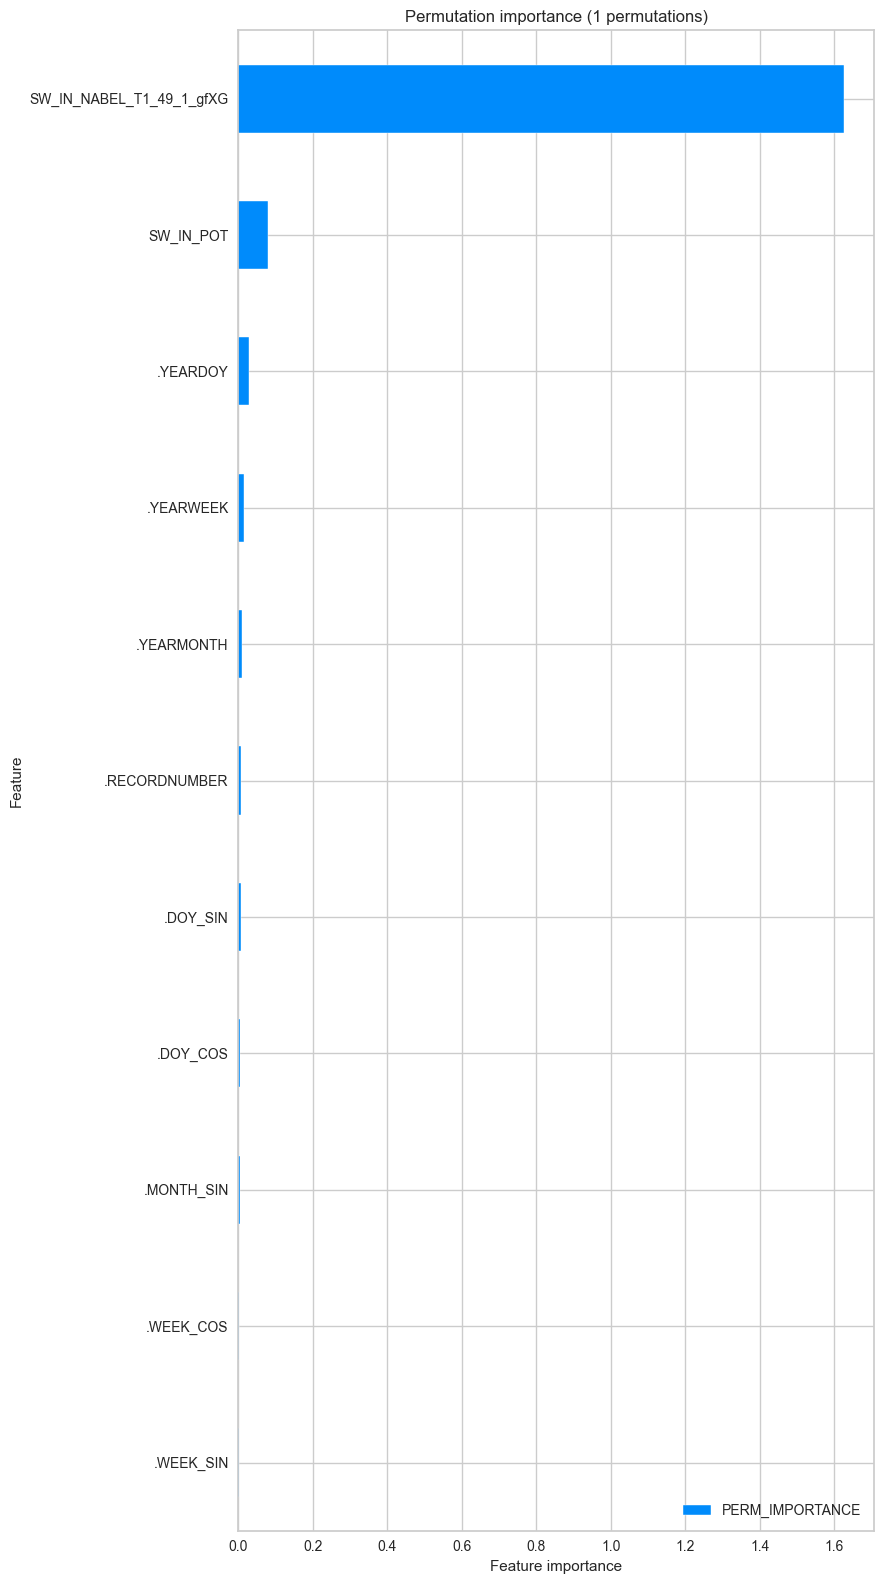

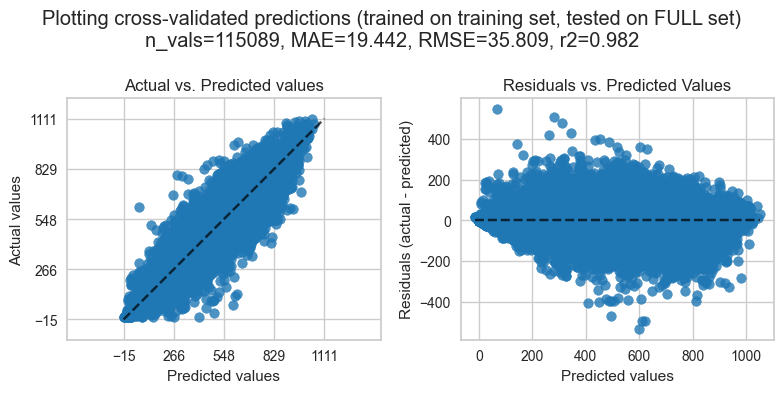

>>> Predicting target SW_IN_T1_47_1 where all features are available ... predicted 131464 records.
>>> Collecting results for final model ...
>>> Filling 16375 missing records in target with predictions from final model ...
>>> Storing gap-filled time series in variable SW_IN_T1_47_1_gfXG ...
>>> Restoring original timestamp in results ...

Gap-filling 0 remaining missing records in SW_IN_T1_47_1_gfXG using fallback model ...
>>> Fallback model not necessary, all gaps were already filled.
>>> Combining predictions from full model and fallback model ...

GAP-FILLING RESULTS

Model scores and feature importances were calculated from high-quality predicted targets (16375 values, SW_IN_T1_47_1_gfXG where flag=1) in comparison to observed targets (115089 values, SW_IN_T1_47_1).

## TARGET
- first timestamp:  2004-01-01 08:45:00
- last timestamp:  2018-12-31 16:15:00
- potential number of values: 131464 values)
- target column (observed):  SW_IN_T1_47_1
- missing records (observed):  16375 (

In [44]:
xgbts.fillgaps(showplot_scores=True, showplot_importance=True)
xgbts.report_gapfilling()

## Results: yearly scores

In [45]:
xgbts.scores_

{'mae': 19.44179699550819,
 'medae': np.float64(9.156463517592513),
 'mse': 1282.3144120788972,
 'rmse': 35.809417924324,
 'mape': 52670317938547.08,
 'maxe': np.float64(545.2736493878895),
 'r2': 0.9820485975410986}

## Results: feature importances

In [46]:
xgbts.feature_importances_

,PERM_IMPORTANCE,PERM_SD
SW_IN_NABEL_T1_49_1_gfXG,1.625983,0.0
SW_IN_POT,0.078417,0.0
.YEARDOY,0.029123,0.0
.YEARWEEK,0.015698,0.0
.YEARMONTH,0.010240,0.0
.RECORDNUMBER,0.006622,0.0
.DOY_SIN,0.006303,0.0
.DOY_COS,0.003631,0.0
.MONTH_SIN,0.003196,0.0
.WEEK_COS,0.001690,0.0


## Results: plot gap-filled time series

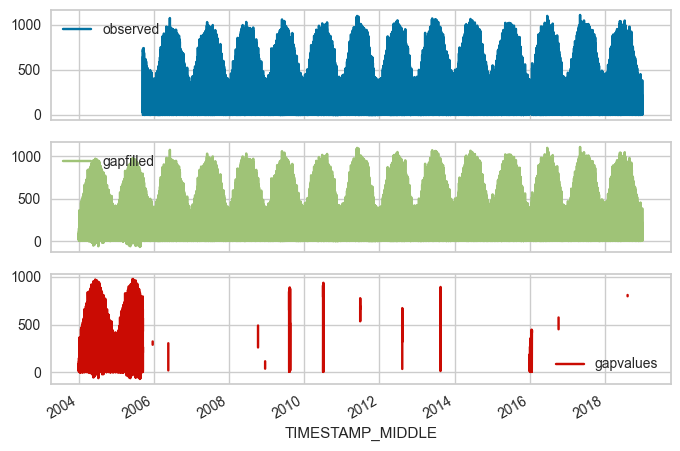

In [47]:
observed = subset[TARGET]
gapfilled = xgbts.get_gapfilled_target()
locs_filled = observed.isna()
gapvalues = gapfilled[locs_filled].copy()
# gapfilled[locs_filled].describe()
_plotdf = pd.DataFrame({
    'observed': observed,
    'gapfilled': gapfilled,
    'gapvalues': gapvalues
})
_plotdf.plot(subplots=True, x_compat=True);

## Add gap-filled daytime series to dataframe and add nighttime data

In [48]:
swin_2004_2018[gapfilled.name] = gapfilled
swin_2004_2018[gapfilled.name] = swin_2004_2018[gapfilled.name].fillna(swin_2004_2018[TARGET])

## Plot time series

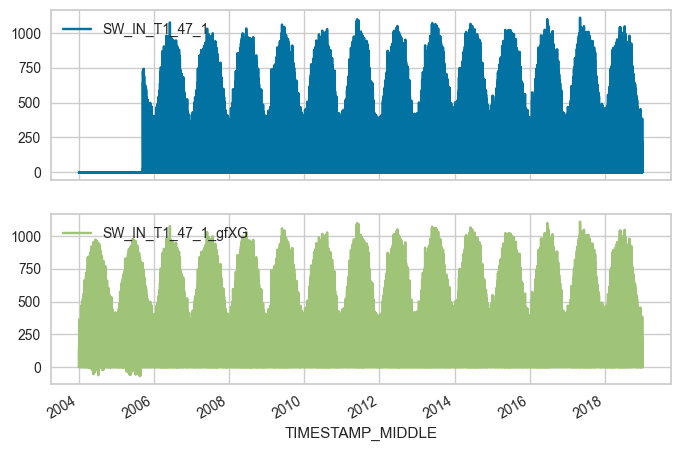

In [49]:
swin_2004_2018[[TARGET, gapfilled.name]].plot(subplots=True, x_compat=True);

## Correction: Remove zero values
- In this case this is not a measurement offset, but an artifact introduced by XGB
- Additional correction needed because gap-filling introduced values < 0

In [50]:
swin_2004_2018[[TARGET, gapfilled.name]].describe()

,SW_IN_T1_47_1,SW_IN_T1_47_1_gfXG
count,246617.000000,262992.000000
mean,133.285417,142.910929
std,231.599271,236.944144
min,0.000000,-70.728065
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,165.034064,191.102238
max,1110.752843,1110.752843


In [51]:
swin_2004_2018[gapfilled.name].loc[swin_2004_2018[gapfilled.name] < 0] = 0
swin_2004_2018[[TARGET, gapfilled.name]].describe()

,SW_IN_T1_47_1,SW_IN_T1_47_1_gfXG
count,246617.000000,262992.000000
mean,133.285417,142.925026
std,231.599271,236.934506
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,165.034064,191.102238
max,1110.752843,1110.752843


In [52]:
# _swin = swin_2004_2025[gapfilled.name].copy()
# _swin_corrected = remove_radiation_zero_offset(series=_swin, lat=SITE_LAT, lon=SITE_LON, utc_offset=1, showplot=True)
# swin_2004_2025[gapfilled.name] = np.nan
# swin_2004_2025[gapfilled.name] = _swin_corrected

</br>

## Dataframe

In [53]:
display(swin_2004_2018)
swin_2004_2018.describe()

,SW_IN_NABEL_T1_49_1,SW_IN_T1_47_1,SW_IN_NABEL_T1_49_1_gfXG,SW_IN_T1_47_1_gfXG
TIMESTAMP_MIDDLE,,,,
2004-01-01 00:15:00,0.0,0.0,0.0,0.0
2004-01-01 00:45:00,0.0,0.0,0.0,0.0
2004-01-01 01:15:00,0.0,0.0,0.0,0.0
2004-01-01 01:45:00,0.0,0.0,0.0,0.0
2004-01-01 02:15:00,0.0,0.0,0.0,0.0
...,...,...,...,...
2018-12-31 21:45:00,0.0,0.0,0.0,0.0
2018-12-31 22:15:00,0.0,0.0,0.0,0.0
2018-12-31 22:45:00,0.0,0.0,0.0,0.0


,SW_IN_NABEL_T1_49_1,SW_IN_T1_47_1,SW_IN_NABEL_T1_49_1_gfXG,SW_IN_T1_47_1_gfXG
count,262774.000000,246617.000000,262992.000000,262992.000000
mean,139.951196,133.285417,140.052094,142.925026
std,233.696653,231.599271,233.695053,236.934506
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000
75%,186.338463,165.034064,186.771366,191.102238
max,1236.721293,1110.752843,1236.721293,1110.752843


</br>

# 🟥 Plots (2004-2018)

## Heatmap

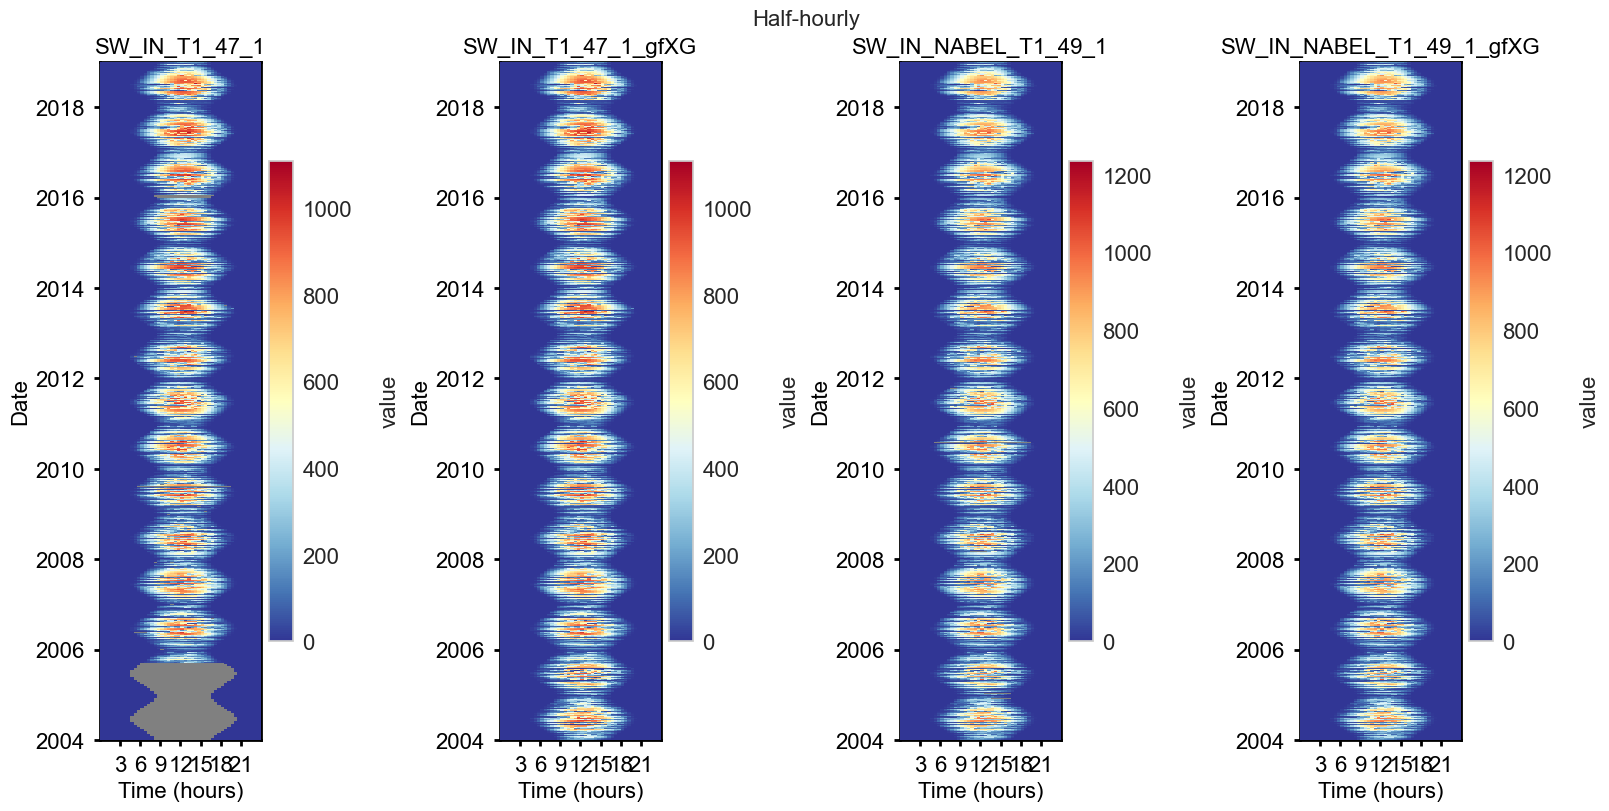

In [54]:
fig, axs = plt.subplots(ncols=4, figsize=(16, 8), dpi=100, layout="constrained")
fig.suptitle(f'Half-hourly', fontsize=16)
dv.heatmapdatetime(series=swin_2004_2018['SW_IN_T1_47_1'], title="SW_IN_T1_47_1", ax=axs[0], cb_digits_after_comma=0, zlabel="value").plot()
dv.heatmapdatetime(series=swin_2004_2018['SW_IN_T1_47_1_gfXG'], title="SW_IN_T1_47_1_gfXG", ax=axs[1], cb_digits_after_comma=0, zlabel="value").plot()
dv.heatmapdatetime(series=swin_2004_2018['SW_IN_NABEL_T1_49_1'], title="SW_IN_NABEL_T1_49_1", ax=axs[2], cb_digits_after_comma=0, zlabel="value").plot()
dv.heatmapdatetime(series=swin_2004_2018['SW_IN_NABEL_T1_49_1_gfXG'], title="SW_IN_NABEL_T1_49_1_gfXG", ax=axs[3], cb_digits_after_comma=0, zlabel="value").plot()

</br>

## Time series plot

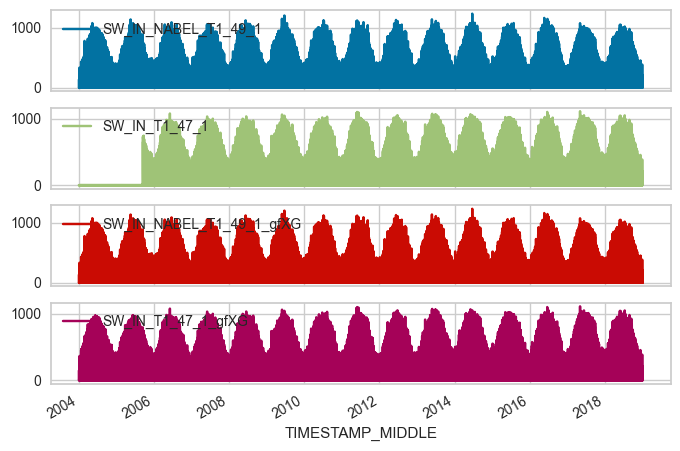

In [55]:
swin_2004_2018.plot(subplots=True, x_compat=True);

</br>

# Prepare dataframe for export

In [69]:
swin_2004_2025

,SW_IN_NABEL_T1_49_1,SW_IN_T1_47_1,SW_IN_NABEL_T1_49_1_gfXG,SW_IN_T1_47_1_gfXG
TIMESTAMP_MIDDLE,,,,
2004-01-01 00:15:00,0.0,0.0,0.0,0.0
2004-01-01 00:45:00,0.0,0.0,0.0,0.0
2004-01-01 01:15:00,0.0,0.0,0.0,0.0
2004-01-01 01:45:00,0.0,0.0,0.0,0.0
2004-01-01 02:15:00,0.0,0.0,0.0,0.0
...,...,...,...,...
2025-12-31 21:45:00,0.0,0.0,0.0,0.0
2025-12-31 22:15:00,0.0,0.0,0.0,0.0
2025-12-31 22:45:00,0.0,0.0,0.0,0.0


In [73]:
export_df = swin_2004_2025.copy()
export_df

,SW_IN_NABEL_T1_49_1,SW_IN_T1_47_1,SW_IN_NABEL_T1_49_1_gfXG,SW_IN_T1_47_1_gfXG
TIMESTAMP_MIDDLE,,,,
2004-01-01 00:15:00,0.0,0.0,0.0,0.0
2004-01-01 00:45:00,0.0,0.0,0.0,0.0
2004-01-01 01:15:00,0.0,0.0,0.0,0.0
2004-01-01 01:45:00,0.0,0.0,0.0,0.0
2004-01-01 02:15:00,0.0,0.0,0.0,0.0
...,...,...,...,...
2025-12-31 21:45:00,0.0,0.0,0.0,0.0
2025-12-31 22:15:00,0.0,0.0,0.0,0.0
2025-12-31 22:45:00,0.0,0.0,0.0,0.0


</br>

# 💾 Save to file

In [74]:
OUTNAME = "02_METEO_SW_IN_GAPFILLED_2004-2025"
OUTPATH = r""
filepath = save_parquet(filename=OUTNAME, data=export_df, outpath=OUTPATH)
export_df.to_csv(Path(OUTPATH) / f"{OUTNAME}.csv")

Saved file 02_METEO_SW_IN_GAPFILLED_2004-2025.parquet (0.165 seconds).


</br>

# End of notebook.

In [75]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")

Finished. 2026-02-26 16:53:14


</br>